<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/01_AnigoCAD_%EB%8D%B0%EC%9D%B4%ED%84%B0%ED%99%95%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!apt-get update -qq
!apt-get install -y -qq unrar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [3]:
!unrar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Usage:     unrar <command> -<switch 1> -<switch N> <archive> <files...>
               <@listfiles...> <path_to_extract\>

<Commands>
  e             Extract files without archived paths
  l[t[a],b]     List archive contents [technical[all], bare]
  p             Print file to stdout
  t             Test archive files
  v[t[a],b]     Verbosely list archive contents [technical[all],bare]
  x             Extract files with full path

<Switches>
  -             Stop switches scanning
  @[+]          Disable [enable] file lists
  ad[1,2]       Alternate destination path
  ag[format]    Generate archive name using the current date
  ai            Ignore file attributes
  ap<path>      Set path inside archive
  c-            Disable comments show
  cfg-          Disable read configuration
  cl            Convert names to lower case
  cu            Convert names to upper case
  dh            Open shared files
  ep     

In [4]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD"
)

RAR_PART1 = PROJECT_DIR / "AngioCAD_Dataset.part1.rar"
FEATURE_FILE = PROJECT_DIR / "AngioCAD_Features.xlsx"
LABELS_FILE = PROJECT_DIR / "AngioCAD_Labels.xlsx"

# colab 압축 해재 경로
EXTRACT_ROOT = Path("/content/AngioCAD")
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

print("프로젝트 경로 :", PROJECT_DIR)
print("압축 해제 경로 :", EXTRACT_ROOT)

프로젝트 경로 : /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
압축 해제 경로 : /content/AngioCAD


In [5]:
if not PROJECT_DIR.exists():
    candidates = list(
        Path("/content/drive/MyDrive").rglob("AngioCAD_Dataset.part1.rar")
    )

    print("검색 결과:", len(candidates))

    for path in candidates:
        print(path)

    if len(candidates) == 1:
        RAR_PART1 = candidates[0]
        PROJECT_DIR = RAR_PART1.parent
        FEATURES_FILE = PROJECT_DIR / "AngioCAD_Features.xlsx"
        LABELS_FILE = PROJECT_DIR / "AngioCAD_Labels.xlsx"

        print("\n자동 선택된 프로젝트 경로:", PROJECT_DIR)
    elif len(candidates) == 0:
        raise FileNotFoundError(
            "Google Drive에서 AngioCAD_Dataset.part1.rar를 찾지 못했습니다."
        )
    else:
        raise RuntimeError(
            "part1.rar가 여러 개 발견됐습니다. 출력된 경로 중 하나를 직접 선택해야 합니다."
        )

In [6]:
rar_parts = [
    PROJECT_DIR / f"AngioCAD_Dataset.part{i}.rar"
    for i in range(1, 5)
]

all_parts_exist = True

for path in rar_parts:
    exists = path.exists()
    size_gb = path.stat().st_size / (1024**3) if exists else 0

    print(
        f"{path.name:30s} "
        f"존재={str(exists):5s} "
        f"크기={size_gb:.2f} GB"
    )

    all_parts_exist &= exists

if not all_parts_exist:
    raise FileNotFoundError(
        "분할압축 파일이 모두 존재하지 않습니다. "
        "part1~part4가 동일 폴더에 있는지 확인하세요."
    )

print("\n분할압축 파일 4개가 모두 확인됐습니다.")

AngioCAD_Dataset.part1.rar     존재=True  크기=3.91 GB
AngioCAD_Dataset.part2.rar     존재=True  크기=3.91 GB
AngioCAD_Dataset.part3.rar     존재=True  크기=3.91 GB
AngioCAD_Dataset.part4.rar     존재=True  크기=3.56 GB

분할압축 파일 4개가 모두 확인됐습니다.


In [7]:
#@title Colab 로컬 저장공간 확인
import shutil

total, used, free = shutil.disk_usage("/content")

print(f"전체 공간 : {total / 1024**3:.1f} GB")
print(f"사용 공간 : {used / 1024**3:.1f} GB")
print(f"남은 공간 : {free / 1024**3:.1f} GB")

if free < 25 * 1024**3 :
    raise RuntimeError(
        "로컬 디스크 여유 공간이 25GB 미만입니다"
        "기존 colab 파일을 정리하거나 런타임을 재시작하세요"
    )

전체 공간 : 225.8 GB
사용 공간 : 20.1 GB
남은 공간 : 205.7 GB


In [8]:
#@title 압축 해제 전 내부 구조 미리 확인
import subprocess

preview = subprocess.run(
    ['unrar', 'lb', str(RAR_PART1)],
    capture_output = True,
    text=True,
    errors="replace",
    check=True,
)

archive_entries = preview.stdout.splitlines()

print("아카이브 내부 파일 수:", len(archive_entries))
print('\n처음 20개 경로:')

for entry in archive_entries[:20]:
    print(entry)

아카이브 내부 파일 수: 32778

처음 20개 경로:
AngioCAD_Dataset/1/1/frame_0000.png
AngioCAD_Dataset/1/1/frame_0001.png
AngioCAD_Dataset/1/1/frame_0002.png
AngioCAD_Dataset/1/1/frame_0003.png
AngioCAD_Dataset/1/1/frame_0004.png
AngioCAD_Dataset/1/1/frame_0005.png
AngioCAD_Dataset/1/1/frame_0006.png
AngioCAD_Dataset/1/1/frame_0007.png
AngioCAD_Dataset/1/1/frame_0008.png
AngioCAD_Dataset/1/1/frame_0009.png
AngioCAD_Dataset/1/1/frame_0010.png
AngioCAD_Dataset/1/1/frame_0011.png
AngioCAD_Dataset/1/1/frame_0012.png
AngioCAD_Dataset/1/1/frame_0013.png
AngioCAD_Dataset/1/1/frame_0014.png
AngioCAD_Dataset/1/1/frame_0015.png
AngioCAD_Dataset/1/1/frame_0016.png
AngioCAD_Dataset/1/1/frame_0017.png
AngioCAD_Dataset/1/1/frame_0018.png
AngioCAD_Dataset/1/1/frame_0019.png


In [9]:
#@title 전체 압축 해제
import subprocess
import time

start_time = time.time()

command = [
    'unrar',
    'x',
    '-o+',
    '-idq',
    str(RAR_PART1),
    str(EXTRACT_ROOT) + '/',
]

print("압축 해제를 시작합니다")
print("입력 :", RAR_PART1)
print("출력 :", EXTRACT_ROOT)

result = subprocess.run(command)

elapsed_min = (time.time() - start_time) / 60

if result.returncode != 0:
    raise RuntimeError(
        f"압축 해제에 실패했습니다"
        f"unrar 종료 코드 : {result.returncode}"
    )

print(f"\n압축 해제 완료 : {elapsed_min:.1f}분")

압축 해제를 시작합니다
입력 : /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/AngioCAD_Dataset.part1.rar
출력 : /content/AngioCAD

압축 해제 완료 : 5.8분


In [10]:
#@title 데이터셋 경로 자동 탐색

from pathlib import Path

# 압축을 해제했던 로컬 경로
EXTRACT_ROOT = Path("/content/AngioCAD")

if not EXTRACT_ROOT.exists():
    raise FileNotFoundError(
        f"압축 해제 경로가 없습니다: {EXTRACT_ROOT}\n"
        "Colab 런타임이 초기화됐다면 RAR 압축 해제부터 다시 실행해야 합니다."
    )

# 숫자로 된 환자 폴더를 포함하는 경로 탐색
dataset_candidates = []

for candidate in [EXTRACT_ROOT, *EXTRACT_ROOT.rglob("*")]:
    if not candidate.is_dir():
        continue

    numeric_dirs = [
        child
        for child in candidate.iterdir()
        if child.is_dir() and child.name.isdigit()
    ]

    if len(numeric_dirs) >= 400:
        dataset_candidates.append((candidate, len(numeric_dirs)))

if not dataset_candidates:
    print("압축 해제 경로의 최상위 내용:")

    for path in EXTRACT_ROOT.iterdir():
        print(" -", path)

    raise FileNotFoundError(
        "413개의 환자 폴더가 들어 있는 데이터셋 경로를 찾지 못했습니다. "
        "압축 해제가 완료됐는지 확인하세요."
    )

# 숫자 환자 폴더가 가장 많이 들어 있는 경로 선택
DATASET_DIR, detected_patient_count = max(
    dataset_candidates,
    key=lambda item: item[1],
)

print("데이터셋 경로:", DATASET_DIR)
print("탐지된 환자 폴더:", detected_patient_count)

데이터셋 경로: /content/AngioCAD/AngioCAD_Dataset
탐지된 환자 폴더: 413


In [11]:
#@title 검증
# 환자 폴더
patient_dirs = sorted(
    [
        path
        for path in DATASET_DIR.iterdir()
        if path.is_dir() and path.name.isdigit()
    ],
    key=lambda path: int(path.name),
)

# Series 폴더
series_dirs = sorted(
    [
        series_dir
        for patient_dir in patient_dirs
        for series_dir in patient_dir.iterdir()
        if series_dir.is_dir() and series_dir.name.isdigit()
    ],
    key=lambda path: (
        int(path.parent.name),
        int(path.name),
    ),
)

# PNG 프레임
png_files = [
    png_file
    for series_dir in series_dirs
    for png_file in series_dir.glob("*.png")
]

print("환자 폴더 수:", len(patient_dirs))
print("Series 폴더 수:", len(series_dirs))
print("PNG 프레임 수:", len(png_files))

if patient_dirs:
    print("첫 번째 환자:", patient_dirs[0])
    print("마지막 환자:", patient_dirs[-1])

if png_files:
    print("첫 번째 PNG:", png_files[0])

assert len(patient_dirs) == 413, (
    f"환자 수가 예상과 다릅니다: {len(patient_dirs)}"
)
assert len(series_dirs) > 0, "Series 폴더를 찾지 못했습니다."
assert len(png_files) > 0, "PNG 파일을 찾지 못했습니다."

print("\n✅ 기본 데이터 구조 검증을 통과했습니다.")

환자 폴더 수: 413
Series 폴더 수: 2711
PNG 프레임 수: 121566
첫 번째 환자: /content/AngioCAD/AngioCAD_Dataset/1
마지막 환자: /content/AngioCAD/AngioCAD_Dataset/413
첫 번째 PNG: /content/AngioCAD/AngioCAD_Dataset/1/1/frame_0051.png

✅ 기본 데이터 구조 검증을 통과했습니다.


모든 series의 프레임 수 확인</br>
프레임 이름과 번호 순서 확인</br>
중간 프레임 누락 여부 확인</br>
손상된 PNG 검사</br>
이미지 크기와 채널 확인</br>
논문 범위인 8–135프레임을 벗어난 series 식별</br>
결과를 Google Drive에 CSV로 저장</br>

In [12]:
#@title 영상 데이터 무결성 검사

from pathlib import Path

# 압축 해제된 데이터셋
DATASET_DIR = Path("/content/AngioCAD/AngioCAD_Dataset")

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"데이터셋 경로가 없습니다: {DATASET_DIR}\n"
        "colab 런타임이 초기화 됐다면 압축 해제부터 다시 진행해야 합니다"
    )
# google Drive에서 AngioCAD 프로젝트 폴더 자동 탐색
part1_candidates = list(
    Path("/content/drive/MyDrive").rglob(
        "AngioCAD_Dataset.part1.rar"
    )
)

if len(part1_candidates) != 1:
    raise RuntimeError(
        f"part1.rar가 {len(part1_candidates)}개 발견됐습니다. "
        "프로젝트 경로를 자동으로 확정할 수 없습니다."
    )

PROJECT_DIR = part1_candidates[0].parent
AUDIT_DIR = PROJECT_DIR / "audit_results"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

print("데이터셋:", DATASET_DIR)
print("프로젝트:", PROJECT_DIR)
print("검사 결과 저장:", AUDIT_DIR)

데이터셋: /content/AngioCAD/AngioCAD_Dataset
프로젝트: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
검사 결과 저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results


In [13]:
#@title 환자와 series 구조 검사

import re
import pandas as pd
from tqdm.auto import tqdm

FRAME_PATTERN = re.compile(
    r"^frame_(\d+)\.png$",
    re.IGNORECASE,
)

patient_dirs = sorted(
    [
        path
        for path in DATASET_DIR.iterdir()
        if path.is_dir() and path.name.isdigit()
    ],
    key = lambda path: int(path.name),
)

series_records =[]
unexpected_files = []

for patient_dir in tqdm(
    patient_dirs,
    desc = "Series 구조 검사",
):
    patient_id = int(patient_dir.name)

    series_dirs = sorted(
        [
            path
            for path in patient_dir.iterdir()
            if path.is_dir() and path.name.isdigit()
        ],
        key = lambda path: int(path.name),
    )

    for series_dir in series_dirs:
        series_id = int(series_dir.name)

        all_files = [
            path
            for path in series_dir.iterdir()
            if path.is_file()
        ]

        frame_paths = []
        frame_indices = []

        for path in all_files :
            match = FRAME_PATTERN.match(path.name)

            if match:
                frame_paths.append(path)
                frame_indices.append(int(match.group(1)))
            else :
                unexpected_files.append({
                    "patient_id" : patient_id,
                    "series_id" : series_id,
                    "file_name" : path.name,
                    "file_path" : str(path),
                })
        frame_indices = sorted(frame_indices)

        if frame_indices :
            first_index = frame_indices[0]
            last_index = frame_indices[-1]

            expected_indices = set(
                range(first_index, last_index + 1)
            )
            actual_indices = set(frame_indices)

            missing_indices = sorted(
                expected_indices - actual_indices
            )

            duplicate_count = (
                len(frame_indices) - len(actual_indices)
            )

        else :
            first_index = None
            last_index = None
            missing_indices = []
            duplicate_count = 0

        series_records.append({
            "patient_id": patient_id,
            "series_id": series_id,
            "series_path": str(series_dir),
            "frame_count": len(frame_paths),
            "first_frame_index": first_index,
            "last_frame_index": last_index,
            "missing_frame_count": len(missing_indices),
            "missing_frame_indices": ",".join(
                map(str, missing_indices)
            ),
            "duplicate_index_count": duplicate_count,
            "below_paper_min_8": len(frame_paths) < 8,
            "above_paper_max_135": len(frame_paths) > 135,
        })

series_manifest_df = pd.DataFrame(series_records)
unexpected_files_df = pd.DataFrame(unexpected_files)

print("검사된 환자 수:", len(patient_dirs))
print("검사된 series 수:", len(series_manifest_df))
print(
    "전체 PNG 수:",
    int(series_manifest_df["frame_count"].sum()),
)

Series 구조 검사:   0%|          | 0/413 [00:00<?, ?it/s]

검사된 환자 수: 413
검사된 series 수: 2711
전체 PNG 수: 121566


In [14]:
#@title 프레임 수 분포와 이상 series확인

from IPython.display import display

frame_summary = (
    series_manifest_df["frame_count"]
    .describe(
        percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

print("series별 프레임 수 요약")
display(frame_summary.to_frame("frame_count"))

short_series_df = (
    series_manifest_df[
        series_manifest_df["frame_count"] < 8
    ]
    .sort_values(["frame_count", "patient_id", "series_id"])
)

long_series_df = (
    series_manifest_df[
        series_manifest_df["frame_count"] > 135
    ]
    .sort_values(
        ["frame_count", "patient_id", "series_id"],
        ascending=[False, True, True],
    )
)

missing_frame_series_df = (
    series_manifest_df[
        series_manifest_df["missing_frame_count"] > 0
    ]
    .sort_values(["patient_id", "series_id"])
)

empty_series_df = (
    series_manifest_df[
        series_manifest_df["frame_count"] == 0
    ]
    .sort_values(]"patient_id", "series_id")
)

print("\n=== 검사 결과 ===")
print("8프레임 미만 series:", len(short_series_df))
print("135프레임 초과 series:", len(long_series_df))
print("중간 프레임 번호 누락 series:", len(missing_frame_series_df))
print("프레임이 없는 series:", len(empty_series_df))
print("예상하지 않은 파일:", len(unexpected_files_df))

print("\n=== 8프레임 미만 series ===")
display(
    short_series_df[
        [
            "patient_id",
            "series_id",
            "frame_count",
            "first_frame_index",
            "last_frame_index",
        ]
    ]
)

print("\n=== 135프레임 초과 series ===")
display(
    long_series_df[
        [
            "patient_id",
            "series_id",
            "frame_count",
            "first_frame_index",
            "last_frame_index",
        ]
    ]
)

if not missing_frame_series_df.empty:
    print("\n=== 프레임 번호가 중간에 누락된 series ===")
    display(
        missing_frame_series_df[
            [
                "patient_id",
                "series_id",
                "frame_count",
                "missing_frame_count",
                "missing_frame_indices",
            ]
        ].head(30)
    )

if not unexpected_files_df.empty:
    print("\n=== 예상하지 않은 파일 ===")
    display(unexpected_files_df.head(30))


series별 프레임 수 요약


,frame_count
count,2711.000000
mean,44.841756
std,23.533278
min,3.000000
1%,12.000000
5%,20.000000
25%,32.000000
50%,42.000000
75%,54.000000
95%,77.000000


In [20]:
#@title 프레임 경로를 정확한 번호순으로 생성

def get_sorted_frame_paths(series_dir) :
    """
    한 sereis 폴더의 PNG를 frame 번호순으로 반환
    """
    series_dir = Path(series_dir)

    indexed_paths = []

    for path in series_dir.iterdir():
        if not path.is_file():
            continue

        match = FRAME_PATTERN.match(path.name)

        if match:
            frame_index = int(match.group(1))
            indexed_paths.append((frame_index, path))

    indexed_paths.sort(key=lambda item: item[0])

    return [path for _, path in indexed_paths]

sample_series_dir = DATASET_DIR / "1" / "1"
sample_frames = get_sorted_frame_paths(sample_series_dir)

print("Sample sereis:", sample_series_dir)
print("프레임 수:", len(sample_frames))
print("처음 5개:")

for path in sample_frames[:5]:
    print(" -", path.name)

print("마지막 5개:")

for path in sample_frames[-5:]:
    print(" -", path.name)

Sample sereis: /content/AngioCAD/AngioCAD_Dataset/1/1
프레임 수: 72
처음 5개:
 - frame_0000.png
 - frame_0001.png
 - frame_0002.png
 - frame_0003.png
 - frame_0004.png
마지막 5개:
 - frame_0067.png
 - frame_0068.png
 - frame_0069.png
 - frame_0070.png
 - frame_0071.png


In [21]:
#@title 모든 PNG 실제 디코딩 검사
# ==> 이름만 존재하다고 정상 이미지는 아님, 모든 PNG를 PIL로 실제 디코딩해서 손상여부 확인

all_png_paths = []
for series_path in tqdm(
    series_manifest_df["series_path"],
    desc="PNG 경로 수집",
):
    all_png_paths.extend(
        get_sorted_frame_paths(series_path)
    )
print("수집된 PNG :", len(all_png_paths))

assert len(all_png_paths) == 121566, (
    f"예상 PNG 수와 다릅니다 : {len(all_png_paths)}"
)

PNG 경로 수집:   0%|          | 0/2711 [00:00<?, ?it/s]

수집된 PNG : 121566


In [23]:
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
from tqdm.auto import tqdm


def inspect_png(path):
    """
    PNG를 실제로 디코딩하고 크기, 모드, 오류를 반환합니다.
    """
    path = Path(path)

    try:
        with Image.open(path) as image:
            image.load()

            width, height = image.size
            mode = image.mode
            image_format = image.format

        return {
            "file_path": str(path),
            "patient_id": int(path.parents[1].name),
            "series_id": int(path.parent.name),
            "file_name": path.name,
            "width": width,
            "height": height,
            "mode": mode,
            "format": image_format,
            "status": "OK",
            "error": "",
        }

    except Exception as error:
        return {
            "file_path": str(path),
            "patient_id": int(path.parents[1].name),
            "series_id": int(path.parent.name),
            "file_name": path.name,
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "status": "ERROR",
            "error": repr(error),
        }


image_records = []

with ThreadPoolExecutor(max_workers=8) as executor:
    results = executor.map(inspect_png, all_png_paths)

    for result in tqdm(
        results,
        total=len(all_png_paths),
        desc="PNG 실제 디코딩 검사",
    ):
        image_records.append(result)

image_audit_df = pd.DataFrame(image_records)

print("전체 검사 이미지:", len(image_audit_df))
print(
    "정상 이미지:",
    int((image_audit_df["status"] == "OK").sum()),
)
print(
    "손상 이미지:",
    int((image_audit_df["status"] == "ERROR").sum()),
)

PNG 실제 디코딩 검사:   0%|          | 0/121566 [00:00<?, ?it/s]

전체 검사 이미지: 121566
정상 이미지: 121566
손상 이미지: 0


In [24]:
#@title 이미지 크기와 채널 분포 확인

valid_images_df = image_audit_df[
    image_audit_df["status"]  == "OK"
].copy()

corrupt_images_df = image_audit_df[
    image_audit_df["status"] == "ERROR"
].copy()

dimension_distribution = (
    valid_images_df
    .groupby(["width", "height", "mode"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

print("이미지 크기 및 채널 분포")
display(dimension_distribution)

if not corrupt_images_df.empty:
    print("\n손상된 이미지")
    display(corrput_images_df)

이미지 크기 및 채널 분포


,width,height,mode,image_count
1,512,512,L,120030
0,1,512,L,1536


In [25]:
#@title 검사 결과 저장
series_manifest_path = (
    AUDIT_DIR / "01_series_manifest.csv"
)

image_audit_path = (
    AUDIT_DIR / "02_image_integrity_audit.csv"
)

unexpected_files_path = (
    AUDIT_DIR / "03_unexpected_files.csv"
)

series_manifest_df.to_csv(
    series_manifest_path,
    index=False,
    encoding="utf-8-sig",
)

image_audit_df.to_csv(
    image_audit_path,
    index=False,
    encoding="utf-8-sig",
)

unexpected_files_df.to_csv(
    unexpected_files_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:")
print(" -", series_manifest_path)
print(" -", image_audit_path)
print(" -", unexpected_files_path)

저장 완료:
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/01_series_manifest.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/02_image_integrity_audit.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/03_unexpected_files.csv


In [26]:
#@title PASS/FAIL 판정

critical_failures = []
warnings = []

if len(patient_dirs) != 413:
    critical_failures.append(
        f"환자 수 불일치: {len(patient_dirs)}"
    )

if len(series_manifest_df) != 2711:
    critical_failures.append(
        f"Series 수 불일치: {len(series_manifest_df)}"
    )

if int(series_manifest_df["frame_count"].sum()) != 121566:
    critical_failures.append(
        "전체 PNG 수 불일치"
    )

if len(empty_series_df) > 0:
    critical_failures.append(
        f"비어 있는 series: {len(empty_series_df)}개"
    )

if len(corrupt_images_df) > 0:
    critical_failures.append(
        f"손상된 PNG: {len(corrupt_images_df)}개"
    )

if len(missing_frame_series_df) > 0:
    warnings.append(
        f"중간 프레임 번호 누락 series: "
        f"{len(missing_frame_series_df)}개"
    )

if len(short_series_df) > 0:
    warnings.append(
        f"논문의 최소 8프레임 미만 series: "
        f"{len(short_series_df)}개"
    )

if len(long_series_df) > 0:
    warnings.append(
        f"논문의 최대 135프레임 초과 series: "
        f"{len(long_series_df)}개"
    )

print("=== 데이터 무결성 판정 ===")

if warnings:
    print("\n경고:")
    for warning in warnings:
        print(" ⚠️", warning)

if critical_failures:
    print("\n중대 오류:")
    for failure in critical_failures:
        print(" ❌", failure)

    raise RuntimeError(
        "영상 데이터 무결성 검사를 통과하지 못했습니다."
    )

print("\n✅ 영상 데이터 무결성 검사를 통과했습니다.")
print(
    "경고 대상 series는 삭제하지 않고 "
    "후속 검사 대상으로 유지합니다."
)

=== 데이터 무결성 판정 ===

경고:
 ⚠️ 논문의 최소 8프레임 미만 series: 9개
 ⚠️ 논문의 최대 135프레임 초과 series: 3개

✅ 영상 데이터 무결성 검사를 통과했습니다.
경고 대상 series는 삭제하지 않고 후속 검사 대상으로 유지합니다.


In [28]:
#@title 1x512 이미지가 포함된 series 특정

abnormal_dimension_df = image_audit_df[
    (image_audit_df["width"] != 512)
    | (image_audit_df["height"] != 512)
].copy()

abnormal_series_summary = (
    abnormal_dimension_df
    .groupby(["patient_id", "series_id"])
    .agg(
        abnormal_image_count=("file_path", "size"),
        width=("width", "first"),
        height = ("height", "first"),
        first_file=("file_name", "min"),
        last_file=("file_name", "max"),
    )
    .reset_index()
)

abnormal_series_summary = abnormal_series_summary.merge(
    series_manifest_df[
        [
            "patient_id",
            "series_id",
            "frame_count",
            "series_path",
        ]
    ],
    on = ["patient_id", "series_id"],
    how="left",
)

display(abnormal_series_summary)

,patient_id,series_id,abnormal_image_count,width,height,first_file,last_file,frame_count,series_path
0,44,3,512,1,512,frame_0000.png,frame_0511.png,512,/content/AngioCAD/AngioCAD_Dataset/44/3
1,301,10,512,1,512,frame_0000.png,frame_0511.png,512,/content/AngioCAD/AngioCAD_Dataset/301/10
2,326,7,512,1,512,frame_0000.png,frame_0511.png,512,/content/AngioCAD/AngioCAD_Dataset/326/7


In [29]:
#@title 자동검증

print(
    "비정상 이미지:",
    len(abnormal_dimension_df),
)

print(
    "비정상 크기가 포함된 series:",
    len(abnormal_series_summary),
)

all_are_1x512 = (
    (abnormal_dimension_df["width"] == 1)
    & (abnormal_dimension_df["height"] == 512)
).all()

all_series_have_512 = (
    abnormal_series_summary["frame_count"] == 512
).all()

print("모두 1×512:", all_are_1x512)
print("각 series가 모두 512개 파일:", all_series_have_512)

비정상 이미지: 1536
비정상 크기가 포함된 series: 3
모두 1×512: True
각 series가 모두 512개 파일: True


In [30]:
#@title 프레임 번호 연속성 확인

import re
from pathlib import Path

FRAME_PATTERN = re.compile(
    r"^frame_(\d+)\.png$",
    re.IGNORECASE,
)

def get_sorted_frame_paths(series_dir):
    indexed_paths = []

    for path in Path(series_dir).glob("*.png"):
        match = FRAME_PATTERN.match(path.name)

        if match :
            indexed_paths.append(
                (int(match.group(1)), path)
            )

    indexed_paths.sort(key=lambda item: item[0])

    return [path for _, path in indexed_paths]

for row in abnormal_series_summary.itertuples():
    frame_paths = get_sorted_frame_paths(row.series_path)
    frame_indices = [
        int(FRAME_PATTERN.match(path.name).group(1))
        for path in frame_paths
    ]

    expected = list(
        range(frame_indices[0], frame_indices[-1] + 1)
    )

    print(
        f"Patient {row.patient_id}, "
        f"Series {row.series_id}"
    )
    print(" 파일 수:", len(frame_paths))
    print(
        " 인덱스:",
        frame_indices[0],
        "~",
        frame_indices[-1],
    )
    print(
        " 연속 여부:",
        frame_indices == expected,
    )


Patient 44, Series 3
 파일 수: 512
 인덱스: 0 ~ 511
 연속 여부: True
Patient 301, Series 10
 파일 수: 512
 인덱스: 0 ~ 511
 연속 여부: True
Patient 326, Series 7
 파일 수: 512
 인덱스: 0 ~ 511
 연속 여부: True


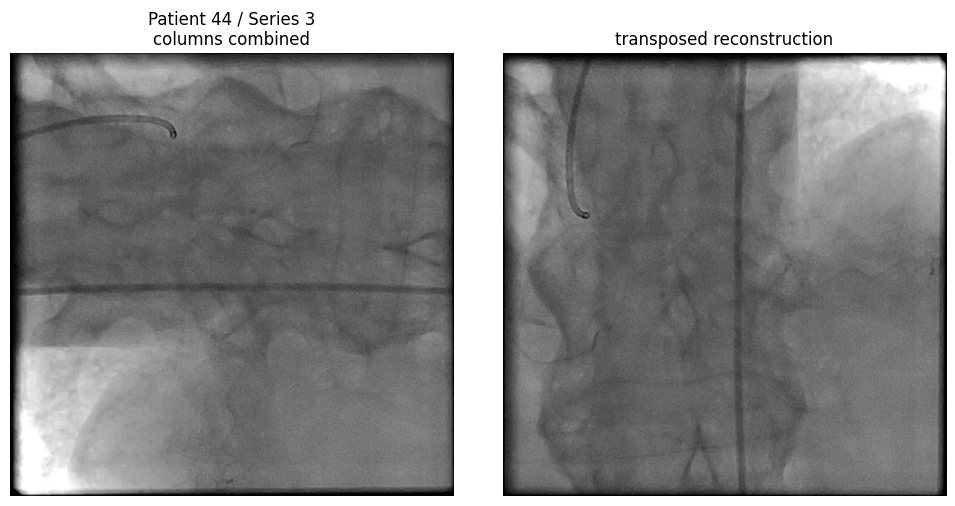

복원 shape: (512, 512) | min: 0 | max: 255 | mean: 109.75 | std: 37.51


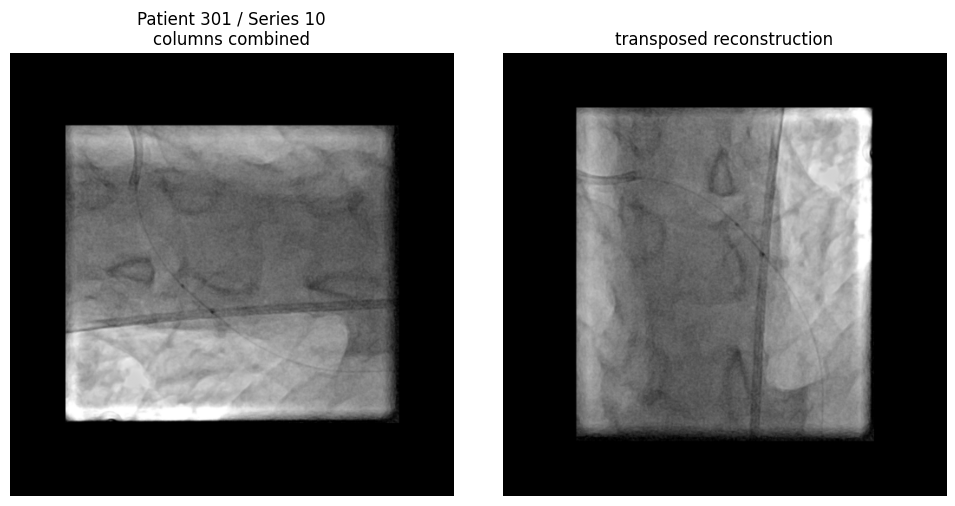

복원 shape: (512, 512) | min: 0 | max: 255 | mean: 63.7 | std: 70.58


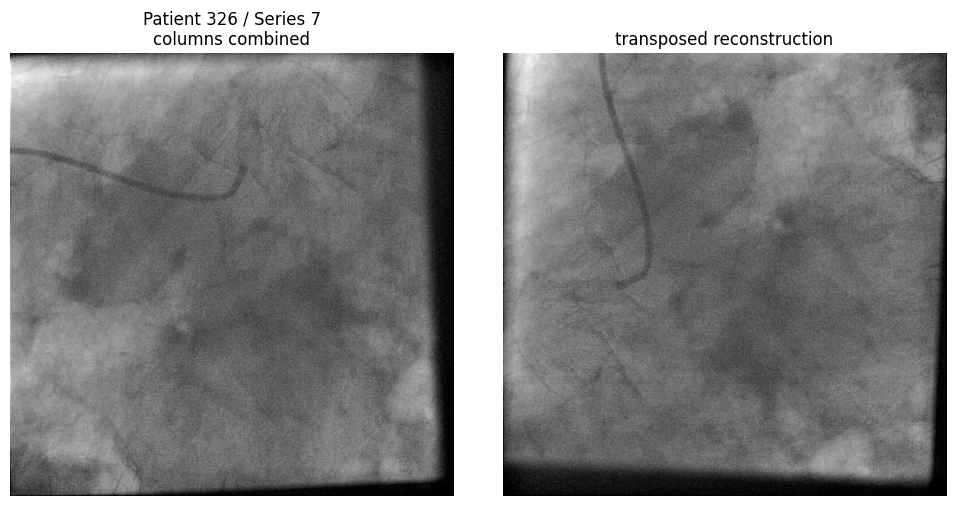

복원 shape: (512, 512) | min: 0 | max: 255 | mean: 107.78 | std: 34.41


In [31]:
#@title 1x512조각 복원 가능성 검사

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def reconstruct_strip_series(series_path):
    frame_paths = get_sorted_frame_paths(series_path)

    strips = []

    for path in frame_paths:
        with Image.open(path) as image:
            array = np.asarray(
                image.convert("L")
            )

        if array.shape != (512, 1):
            raise ValueError(
                f"예상하지 않은 shape: "
                f"{path} → {array.shape}"
            )

        strips.append(array[:, 0])

    # 각 1×512 이미지를 세로 열로 간주
    reconstructed = np.stack(
        strips,
        axis=1,
    )

    return reconstructed


for row in abnormal_series_summary.itertuples():
    reconstructed = reconstruct_strip_series(
        row.series_path
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5),
    )

    axes[0].imshow(
        reconstructed,
        cmap="gray",
    )
    axes[0].set_title(
        f"Patient {row.patient_id} / "
        f"Series {row.series_id}\n"
        "columns combined"
    )
    axes[0].axis("off")

    axes[1].imshow(
        reconstructed.T,
        cmap="gray",
    )
    axes[1].set_title(
        "transposed reconstruction"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(
        "복원 shape:",
        reconstructed.shape,
        "| min:",
        reconstructed.min(),
        "| max:",
        reconstructed.max(),
        "| mean:",
        round(float(reconstructed.mean()), 2),
        "| std:",
        round(float(reconstructed.std()), 2),
    )

In [33]:
#@title 복원 preview만 저장

PREVIEW_DIR = (
    AUDIT_DIR / "reconstructed_1x512_previews"
)

PREVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for row in abnormal_series_summary.itertuples():
    reconstructed = reconstruct_strip_series(
        row.series_path
    )

    output_path = (
        PREVIEW_DIR
        / (
            f"patient_{int(row.patient_id):03d}"
            f"_series_{int(row.series_id):02d}"
            f"_reconstructed.png"
        )
    )

    Image.fromarray(
        reconstructed.astype(np.uint8),
        mode="L",
    ).save(output_path)

    transpose_path = (
        PREVIEW_DIR
        / (
            f"patient_{int(row.patient_id):03d}"
            f"_series_{int(row.series_id):02d}"
            f"_transposed.png"
        )
    )

    Image.fromarray(
        reconstructed.T.astype(np.uint8),
        mode="L",
    ).save(transpose_path)

    print("저장:", output_path)
    print("저장:", transpose_path)

/tmp/ipykernel_836/2041265107.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(
/tmp/ipykernel_836/2041265107.py:40: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/reconstructed_1x512_previews/patient_044_series_03_reconstructed.png
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/reconstructed_1x512_previews/patient_044_series_03_transposed.png
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/reconstructed_1x512_previews/patient_301_series_10_reconstructed.png
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/reconstructed_1x512_previews/patient_301_series_10_transposed.png
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/reconstructed_1x512_previews/patient_326_series_07_reconstructed.png
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/reconstructed_1x512_previews/patient_326_series_07_transposed.png


In [34]:
#@title 짧은 series 9개 검사
# 8프레임 미만 전체 확인

short_series_df = (
    series_manifest_df[
        series_manifest_df["frame_count"] < 8
    ]
    .sort_values(
        ["frame_count", "patient_id", "series_id"]
    )
)

display(
    short_series_df[
        [
            "patient_id",
            "series_id",
            "frame_count",
            "first_frame_index",
            "last_frame_index",
            "missing_frame_count",
            "series_path",
        ]
    ]
)

print(
    "5프레임 미만:",
    int(
        (
            short_series_df["frame_count"] < 5
        ).sum()
    ),
)

print(
    "5–7프레임:",
    int(
        (
            short_series_df["frame_count"]
            .between(5, 7)
        ).sum()
    ),
)

,patient_id,series_id,frame_count,first_frame_index,last_frame_index,missing_frame_count,series_path
897,159,4,3,0,2,0,/content/AngioCAD/AngioCAD_Dataset/159/4
1896,301,20,3,0,2,0,/content/AngioCAD/AngioCAD_Dataset/301/20
2692,411,1,3,0,2,0,/content/AngioCAD/AngioCAD_Dataset/411/1
1885,301,9,4,0,3,0,/content/AngioCAD/AngioCAD_Dataset/301/9
2710,413,4,4,0,3,0,/content/AngioCAD/AngioCAD_Dataset/413/4
548,95,5,6,0,5,0,/content/AngioCAD/AngioCAD_Dataset/95/5
2161,335,7,6,0,5,0,/content/AngioCAD/AngioCAD_Dataset/335/7
1897,301,21,7,0,6,0,/content/AngioCAD/AngioCAD_Dataset/301/21
2696,411,5,7,0,6,0,/content/AngioCAD/AngioCAD_Dataset/411/5


5프레임 미만: 5
5–7프레임: 4


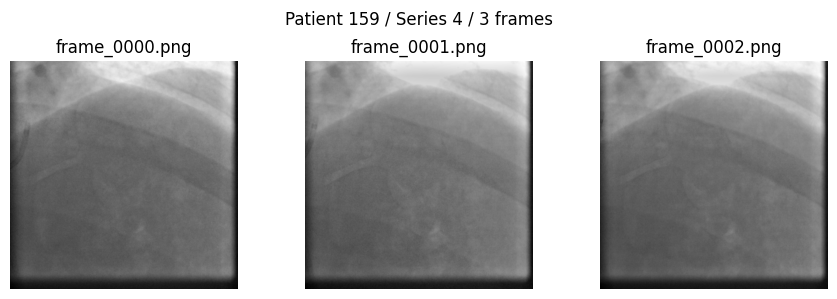

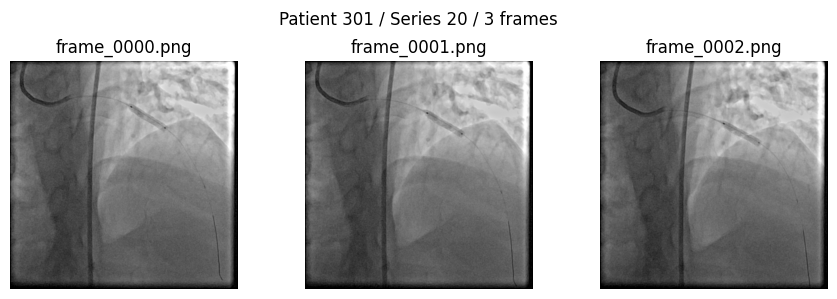

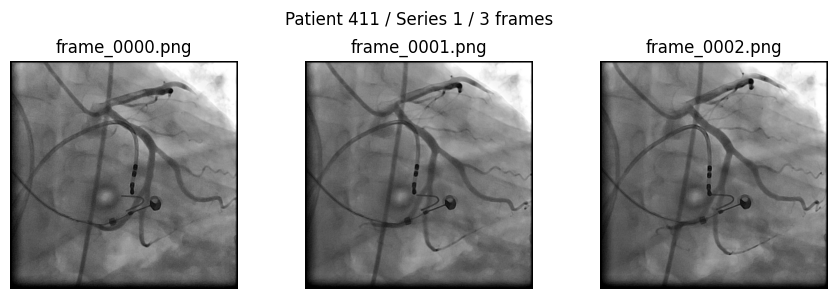

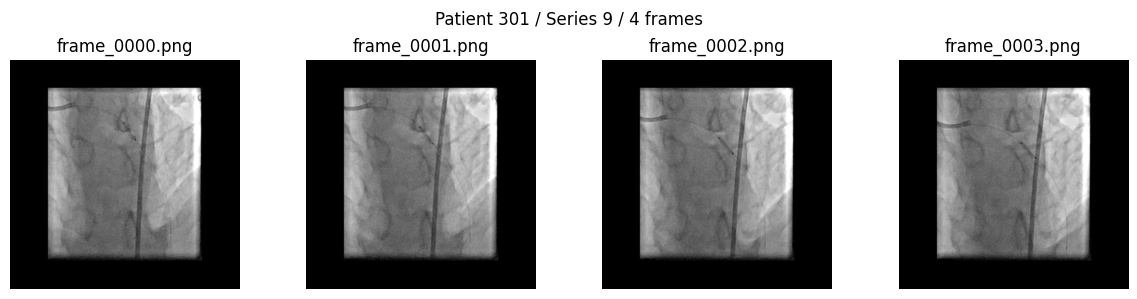

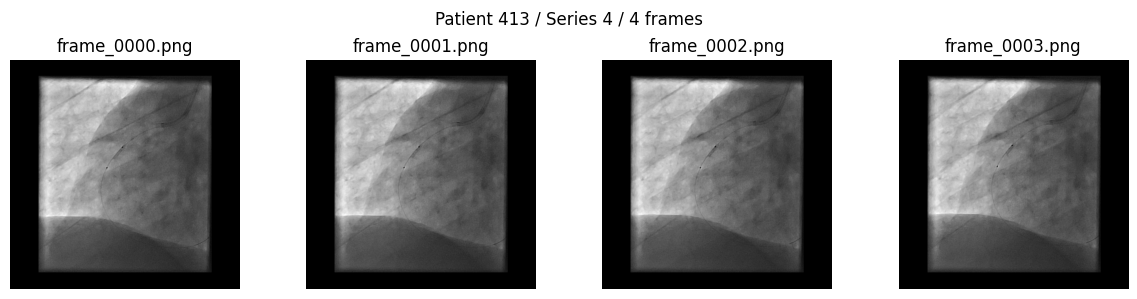

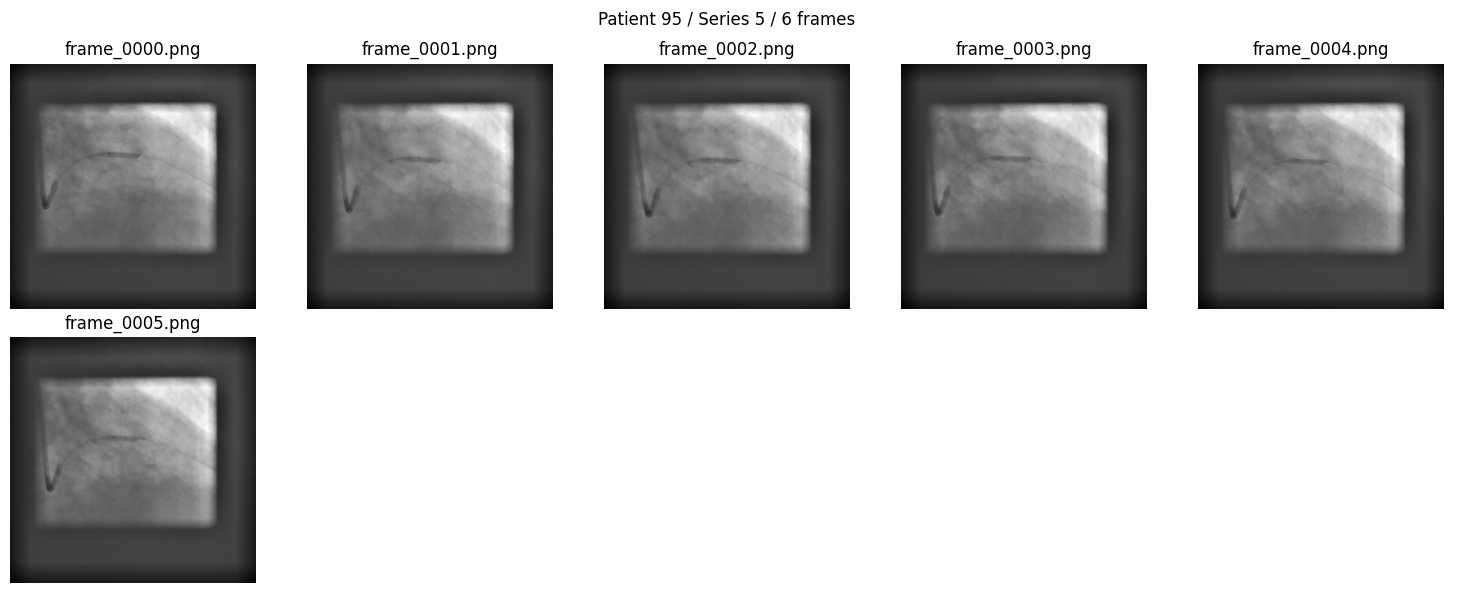

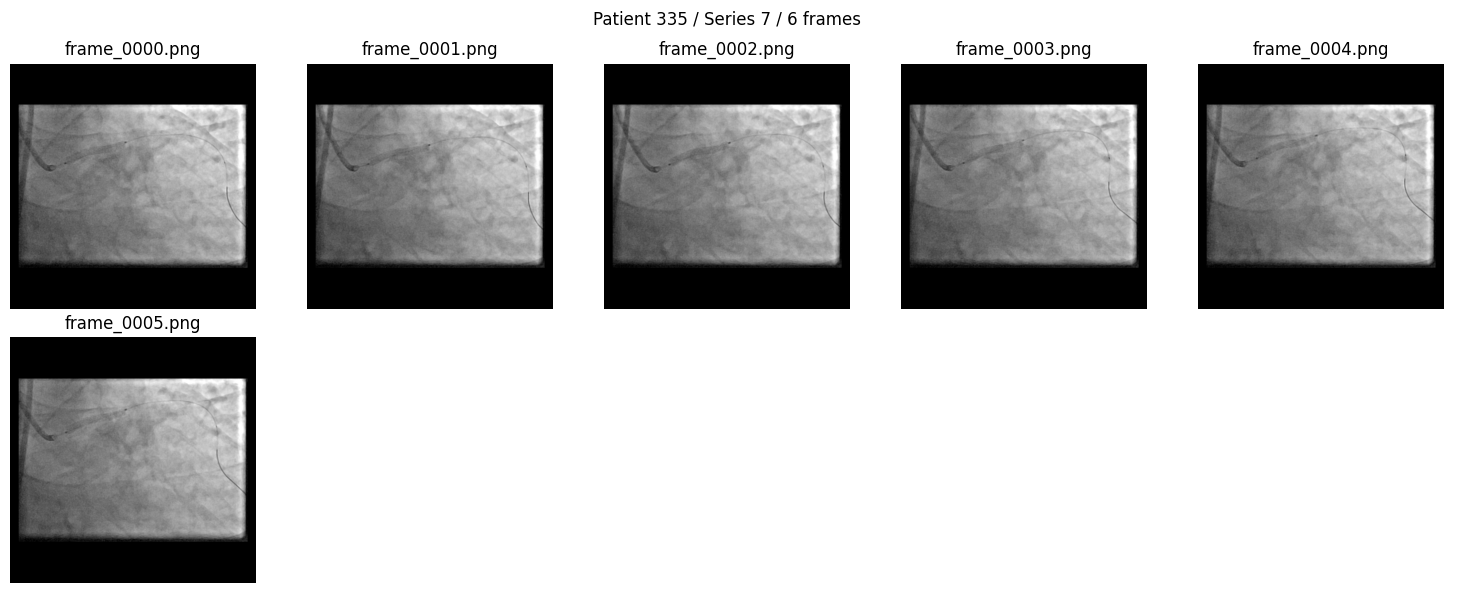

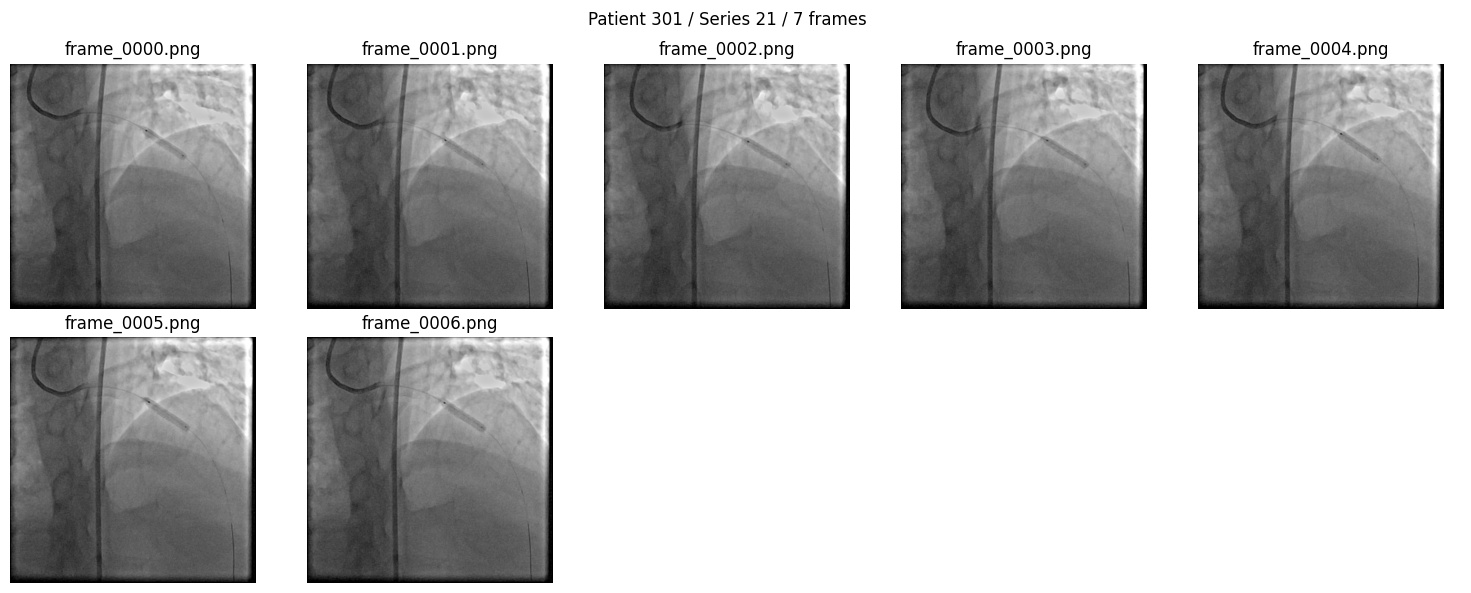

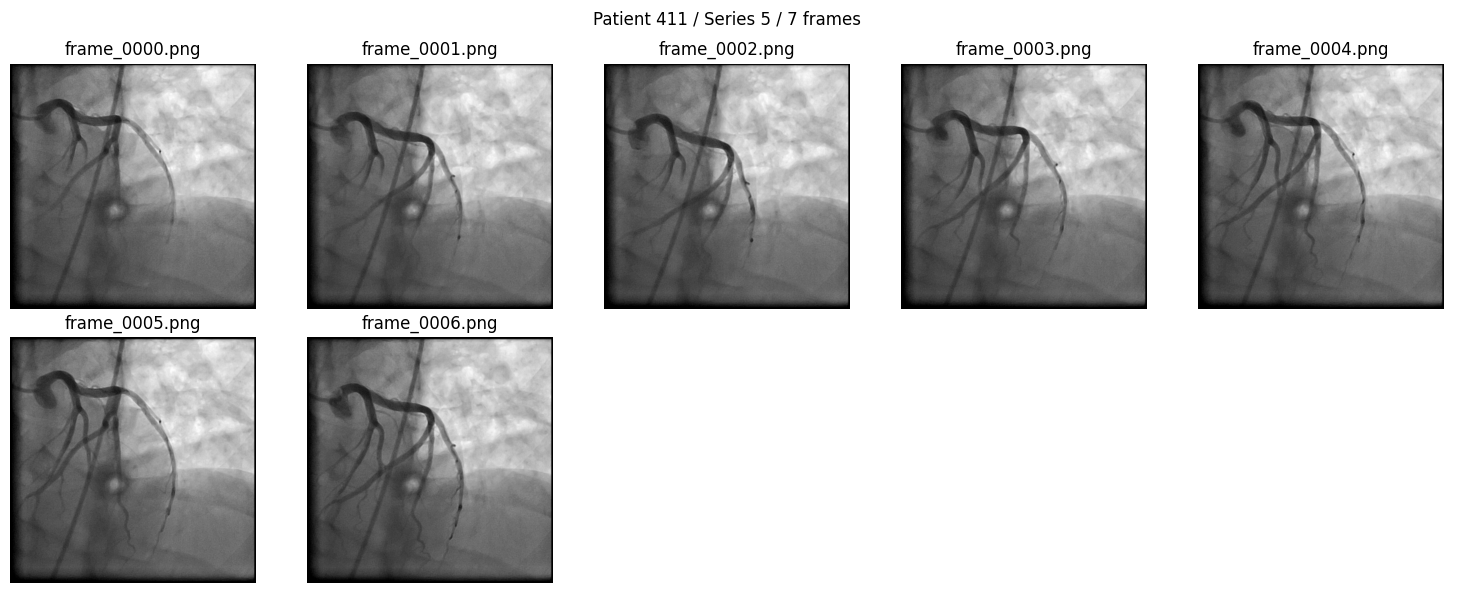

In [35]:
#@title 짧은 series 전체 프레임 시각화

import math

for row in short_series_df.itertuples():
    frame_paths = get_sorted_frame_paths(
        row.series_path
    )

    number_of_frames = len(frame_paths)
    number_of_columns = min(5, number_of_frames)
    number_of_rows = math.ceil(
        number_of_frames / number_of_columns
    )

    fig, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(
            number_of_columns * 3,
            number_of_rows * 3,
        ),
        squeeze=False,
    )

    for axis in axes.flat:
        axis.axis("off")

    for axis, path in zip(
        axes.flat,
        frame_paths,
    ):
        with Image.open(path) as image:
            axis.imshow(
                image,
                cmap="gray",
            )

        axis.set_title(path.name)
        axis.axis("off")

    fig.suptitle(
        f"Patient {row.patient_id} / "
        f"Series {row.series_id} / "
        f"{number_of_frames} frames"
    )

    plt.tight_layout()
    plt.show()


In [36]:
#@title 이상 sereis 저장

abnormal_series_path = (
    AUDIT_DIR / "04_abnormal_dimension_series.csv"
)

short_series_path = (
    AUDIT_DIR / "05_short_series.csv"
)

abnormal_series_summary.to_csv(
    abnormal_series_path,
    index=False,
    encoding="utf-8-sig",
)

short_series_df.to_csv(
    short_series_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:")
print(" -", abnormal_series_path)
print(" -", short_series_path)

저장 완료:
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/04_abnormal_dimension_series.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/05_short_series.csv


In [38]:
#@title manifest 생성 / series별 영상 크기 정보 결합

dimension_by_series_df = (
    image_audit_df
    .groupby(["patient_id", "series_id"])
    .agg(
        image_count = ("file_path", "size"),
        width_min = ("width", "min"),
        width_max = ("width", "max"),
        height_min = ("height", "min"),
        height_max = ("height", "max"),
        dimension_count =(
            "file_path",
            lambda paths : len(paths),
        ),
        error_count =(
            "status",
            lambda values: int(
                (values != "OK").sum()
            ),
        ),
    )
    .reset_index()
)

series_quality_df = series_manifest_df.merge(
    dimension_by_series_df,
    on=["patient_id", "series_id"],
    how="left",
    validate = "one_to_one",
)

print("Series quality rows:", len(series_quality_df))

assert len(series_quality_df)  == len(series_manifest_df)

Series quality rows: 2711


In [41]:
#@title 정확한 크기 종류 수 추가

dimension_type_count_df = (
    image_audit_df
    .groupby(["patient_id", "series_id"])
    .apply(
        lambda group : len(
            group[
                ["width", "height", "mode"]
            ].drop_duplicates()
        ),
        include_groups=False,
    )
    .rename("dimension_type_count")
    .reset_index()
)

series_quality_df = series_quality_df.merge(
    dimension_type_count_df,
    on = ["patient_id", "series_id"],
    how="left",
    validate = "one_to_one",
)

In [42]:
#@title 객관적인 품질 상태 부여

def assign_quality_status(row) :
    if row["error_count"] > 0:
        return "EXCLUDE_CORRUPT_IMAGE"

    standard_dimensions = (
        row["width_min"] == 512
        and row["width_max"] == 512
        and row["height_min"] == 512
        and row["height_max"] == 512
    )

    if not standard_dimensions:
        return "EXCLUDE_NONSTANDARD_DIMENSION"

    if row["frame_count"] < 5:
        return "EXCLUDE_INSUFFICIENT_FRAMES"

    if row["frame_count"] < 8:
        return "EXTENDED_ONLY_SHORT_SEQUENCE"

    if row["frame_count"] > 135:
        return "EXCLUDE_ABOVE_PAPER_RANGE"

    return "INCLUDE_PAPER_AND_EXTENDED"


series_quality_df["quality_status"] = (
    series_quality_df.apply(
        assign_quality_status,
        axis=1,
    )
)

print("=== 품질 상태 분포 ===")

display(
    series_quality_df[
        "quality_status"
    ].value_counts().to_frame("series_count")
)

=== 품질 상태 분포 ===


,series_count
quality_status,
INCLUDE_PAPER_AND_EXTENDED,2699
EXCLUDE_INSUFFICIENT_FRAMES,5
EXTENDED_ONLY_SHORT_SEQUENCE,4
EXCLUDE_NONSTANDARD_DIMENSION,3


In [43]:
#@title paper/extended cohort 생성

paper_eligible_statuses = {
    "INCLUDE_PAPER_AND_EXTENDED",
}

extended_eligible_statuses = {
    "INCLUDE_PAPER_AND_EXTENDED",
    "EXTENDED_ONLY_SHORT_SEQUENCE",
}

paper_series_df = (
    series_quality_df[
        series_quality_df["quality_status"]
        .isin(paper_eligible_statuses)
    ]
    .copy()
    .reset_index(drop=True)
)

extended_series_df = (
    series_quality_df[
        series_quality_df["quality_status"]
        .isin(extended_eligible_statuses)
    ]
    .copy()
    .reset_index(drop=True)
)

excluded_series_df = (
    series_quality_df[
        ~series_quality_df["quality_status"]
        .isin(extended_eligible_statuses)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Paper cohort series:", len(paper_series_df))
print("Extended cohort series:", len(extended_series_df))
print("Main exclusion series:", len(excluded_series_df))

print(
    "\nPaper cohort 환자 수:",
    paper_series_df["patient_id"].nunique(),
)

print(
    "Extended cohort 환자 수:",
    extended_series_df["patient_id"].nunique(),
)

Paper cohort series: 2699
Extended cohort series: 2703
Main exclusion series: 8

Paper cohort 환자 수: 412
Extended cohort 환자 수: 412


In [44]:
#@title 제외 확장 대상 최종 확인

print("=== 논문 재현에서는 제외되지만 확장 실험에는 포함 ===")

display(
    extended_series_df[
        extended_series_df["quality_status"]
        == "EXTENDED_ONLY_SHORT_SEQUENCE"
    ][
        [
            "patient_id",
            "series_id",
            "frame_count",
            "quality_status",
            "series_path",
        ]
    ]
)

print("\n=== Main dataset에서 제외 ===")

display(
    excluded_series_df[
        [
            "patient_id",
            "series_id",
            "frame_count",
            "width_min",
            "width_max",
            "height_min",
            "height_max",
            "quality_status",
            "series_path",
        ]
    ]
)

=== 논문 재현에서는 제외되지만 확장 실험에는 포함 ===


,patient_id,series_id,frame_count,quality_status,series_path
547,95,5,6,EXTENDED_ONLY_SHORT_SEQUENCE,/content/AngioCAD/AngioCAD_Dataset/95/5
1892,301,21,7,EXTENDED_ONLY_SHORT_SEQUENCE,/content/AngioCAD/AngioCAD_Dataset/301/21
2155,335,7,6,EXTENDED_ONLY_SHORT_SEQUENCE,/content/AngioCAD/AngioCAD_Dataset/335/7
2689,411,5,7,EXTENDED_ONLY_SHORT_SEQUENCE,/content/AngioCAD/AngioCAD_Dataset/411/5



=== Main dataset에서 제외 ===


,patient_id,series_id,frame_count,width_min,width_max,height_min,height_max,quality_status,series_path
0,44,3,512,1,1,512,512,EXCLUDE_NONSTANDARD_DIMENSION,/content/AngioCAD/AngioCAD_Dataset/44/3
1,159,4,3,512,512,512,512,EXCLUDE_INSUFFICIENT_FRAMES,/content/AngioCAD/AngioCAD_Dataset/159/4
2,301,9,4,512,512,512,512,EXCLUDE_INSUFFICIENT_FRAMES,/content/AngioCAD/AngioCAD_Dataset/301/9
3,301,10,512,1,1,512,512,EXCLUDE_NONSTANDARD_DIMENSION,/content/AngioCAD/AngioCAD_Dataset/301/10
4,301,20,3,512,512,512,512,EXCLUDE_INSUFFICIENT_FRAMES,/content/AngioCAD/AngioCAD_Dataset/301/20
5,326,7,512,1,1,512,512,EXCLUDE_NONSTANDARD_DIMENSION,/content/AngioCAD/AngioCAD_Dataset/326/7
6,411,1,3,512,512,512,512,EXCLUDE_INSUFFICIENT_FRAMES,/content/AngioCAD/AngioCAD_Dataset/411/1
7,413,4,4,512,512,512,512,EXCLUDE_INSUFFICIENT_FRAMES,/content/AngioCAD/AngioCAD_Dataset/413/4


In [45]:
#@title 검증 assert
assert len(series_quality_df) == 2711, (
    f"전체 series 수 오류: {len(series_quality_df)}"
)

assert len(paper_series_df) == 2699, (
    f"Paper cohort 수가 예상과 다릅니다: "
    f"{len(paper_series_df)}"
)

assert len(extended_series_df) == 2703, (
    f"Extended cohort 수가 예상과 다릅니다: "
    f"{len(extended_series_df)}"
)

assert (
    paper_series_df["width_min"].eq(512).all()
    and paper_series_df["width_max"].eq(512).all()
    and paper_series_df["height_min"].eq(512).all()
    and paper_series_df["height_max"].eq(512).all()
), "Paper cohort에 비표준 이미지가 포함됐습니다."

assert paper_series_df["frame_count"].between(
    8,
    135,
).all(), "Paper cohort의 프레임 범위가 잘못됐습니다."

assert extended_series_df["frame_count"].ge(5).all(), (
    "Extended cohort에 5프레임 미만 series가 포함됐습니다."
)

print("✅ Series 품질 정책 검증을 통과했습니다.")

✅ Series 품질 정책 검증을 통과했습니다.


In [46]:
#@title 결과 저장

quality_policy_path = (
    AUDIT_DIR / "06_series_quality_policy.csv"
)

paper_cohort_path = (
    AUDIT_DIR / "07_paper_eligible_series.csv"
)

extended_cohort_path = (
    AUDIT_DIR / "08_extended_eligible_series.csv"
)

excluded_cohort_path = (
    AUDIT_DIR / "09_excluded_series.csv"
)

series_quality_df.to_csv(
    quality_policy_path,
    index=False,
    encoding="utf-8-sig",
)

paper_series_df.to_csv(
    paper_cohort_path,
    index=False,
    encoding="utf-8-sig",
)

extended_series_df.to_csv(
    extended_cohort_path,
    index=False,
    encoding="utf-8-sig",
)

excluded_series_df.to_csv(
    excluded_cohort_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:")
print(" -", quality_policy_path)
print(" -", paper_cohort_path)
print(" -", extended_cohort_path)
print(" -", excluded_cohort_path)

저장 완료:
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/06_series_quality_policy.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/07_paper_eligible_series.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/08_extended_eligible_series.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/09_excluded_series.csv


In [48]:
#@title excel,환자,right/left series 매핑검사

from pathlib import Path
import pandas as pd

label_candidates = list(
    PROJECT_DIR.glob("AngioCAD_Labels.xlsx")
)

feature_candidates = list(
    PROJECT_DIR.glob("AngioCAD_Features.xlsx")
)

if len(label_candidates) != 1:
    raise RuntimeError(
        f"Labels 파일 검색 결과 : {len(label_candidates)}개"
    )

if len(feature_candidates) != 1:
    raise RuntimeError(
        f"features 파일 검색 결과 : {len(label_candidates)}개"
    )

LABELS_FILE = label_candidates[0]
FEATURES_FILE = feature_candidates[0]

labels_df = pd.read_excel(
    LABELS_FILE,
    sheet_name= "Labels",
)

features_df = pd.read_excel(
    FEATURES_FILE,
    sheet_name = "Main",
)

print("Labels:", labels_df.shape)
print("Features:", features_df.shape)

print("\nLabels 파일:", LABELS_FILE)
print("Features 파일:", FEATURES_FILE)

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Labels: (413, 18)
Features: (377, 60)

Labels 파일: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/AngioCAD_Labels.xlsx
Features 파일: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/AngioCAD_Features.xlsx


In [49]:
#@title ID 자료형 통일 및 중복 검사

labels_df["ID"] = pd.to_numeric(
    labels_df["ID"],
    errors="raise",
).astype(int)

features_df["ID"] = pd.to_numeric(
    features_df["ID"],
    errors="raise",
).astype(int)

label_duplicate_count = int(
    labels_df["ID"].duplicated().sum()
)

feature_duplicate_count = int(
    features_df["ID"].duplicated().sum()
)

print("Labels 중복 ID:", label_duplicate_count)
print("Features 중복 ID:", feature_duplicate_count)

assert label_duplicate_count == 0
assert feature_duplicate_count == 0

print("✅ Excel ID 중복 검사를 통과했습니다.")

Labels 중복 ID: 0
Features 중복 ID: 0
✅ Excel ID 중복 검사를 통과했습니다.


In [50]:
#@title 영상, 라벨, 임상정보 환자 ID 비교

folder_patient_ids = {
    int(path.name)
    for path in DATASET_DIR.iterdir()
    if path.is_dir() and path.name.isdigit()
}

all_series_patient_ids = set(
    series_quality_df["patient_id"].astype(int)
)

paper_patient_ids = set(
    paper_series_df["patient_id"].astype(int)
)

extended_patient_ids = set(
    extended_series_df["patient_id"].astype(int)
)

label_patient_ids = set(
    labels_df["ID"].astype(int)
)

clinical_patient_ids = set(
    features_df["ID"].astype(int)
)

print("환자 폴더:", len(folder_patient_ids))
print("실제 series가 있는 환자:", len(all_series_patient_ids))
print("Paper cohort 환자:", len(paper_patient_ids))
print("Extended cohort 환자:", len(extended_patient_ids))
print("Labels 환자:", len(label_patient_ids))
print("Clinical 환자:", len(clinical_patient_ids))

print(
    "\n폴더는 있지만 series가 없는 환자:",
    sorted(folder_patient_ids - all_series_patient_ids),
)

print(
    "Labels는 있지만 환자 폴더가 없는 경우:",
    sorted(label_patient_ids - folder_patient_ids),
)

print(
    "환자 폴더는 있지만 Labels가 없는 경우:",
    sorted(folder_patient_ids - label_patient_ids),
)

print(
    "\nLabels는 있지만 Clinical 정보가 없는 환자 수:",
    len(label_patient_ids - clinical_patient_ids),
)

print(
    "Clinical 정보가 없는 환자 ID:",
    sorted(label_patient_ids - clinical_patient_ids),
)

환자 폴더: 413
실제 series가 있는 환자: 412
Paper cohort 환자: 412
Extended cohort 환자: 412
Labels 환자: 413
Clinical 환자: 377

폴더는 있지만 series가 없는 환자: [157]
Labels는 있지만 환자 폴더가 없는 경우: []
환자 폴더는 있지만 Labels가 없는 경우: []

Labels는 있지만 Clinical 정보가 없는 환자 수: 36
Clinical 정보가 없는 환자 ID: [28, 77, 104, 108, 126, 133, 150, 166, 167, 171, 194, 195, 197, 222, 233, 234, 253, 258, 260, 278, 282, 291, 294, 295, 300, 307, 309, 311, 316, 334, 340, 345, 352, 355, 371, 400]


In [51]:
#@title ID 검사 자동 판정

id_failures = []
id_warnings = []

if folder_patient_ids != label_patient_ids:
    id_failures.append(
        "영상 환자 폴더와 Labels ID가 일치하지 않음"
    )

empty_patient_ids = (
    folder_patient_ids - all_series_patient_ids
)

if empty_patient_ids:
    id_warnings.append(
        f"Series가 없는 환자: "
        f"{sorted(empty_patient_ids)}"
    )

missing_clinical_ids = (
    label_patient_ids - clinical_patient_ids
)

if missing_clinical_ids:
    id_warnings.append(
        f"Clinical 정보가 없는 환자: "
        f"{len(missing_clinical_ids)}명"
    )

print("=== 환자 ID 검사 ===")

for warning in id_warnings:
    print("⚠️", warning)

if id_failures:
    for failure in id_failures:
        print("❌", failure)

    raise RuntimeError(
        "환자 ID 검사를 통과하지 못했습니다."
    )

print("\n✅ 영상 폴더와 Labels 환자 ID가 일치합니다.")

=== 환자 ID 검사 ===
⚠️ Series가 없는 환자: [157]
⚠️ Clinical 정보가 없는 환자: 36명

✅ 영상 폴더와 Labels 환자 ID가 일치합니다.


In [52]:
#@title Right/Left series 문자열 해석
# Right Coronary sereis = 1-2
# Left Coronary Seris = 3-9

#안전한 series 범위 parser

import re
import numbers
import numpy as np


def parse_series_spec(value):
    """
    Excel series 표기를 정수 집합으로 변환합니다.

    예:
      3       -> {3}
      3.0     -> {3}
      '1-3'   -> {1, 2, 3}
      '1,3-5' -> {1, 3, 4, 5}
    """
    if pd.isna(value):
        return set()

    if isinstance(value, numbers.Number):
        return {int(value)}

    text = str(value).strip()

    text = (
        text
        .replace("–", "-")
        .replace("—", "-")
        .replace("−", "-")
    )

    # Excel에서 문자열 '3.0'으로 읽힌 경우
    text = re.sub(
        r"(?<=\d)\.0\b",
        "",
        text,
    )

    result = set()

    tokens = re.findall(
        r"\d+\s*-\s*\d+|\d+",
        text,
    )

    for token in tokens:
        if "-" in token:
            start_text, end_text = re.split(
                r"\s*-\s*",
                token,
            )

            start = int(start_text)
            end = int(end_text)

            if end < start:
                raise ValueError(
                    f"잘못된 series 범위: {value}"
                )

            result.update(
                range(start, end + 1)
            )
        else:
            result.add(int(token))

    if not result and text:
        raise ValueError(
            f"해석할 수 없는 series 표기: {value}"
        )

    return result

In [53]:
#@title test
parser_tests = {
    "1-2": {1, 2},
    "3-9": {3, 4, 5, 6, 7, 8, 9},
    3: {3},
    3.0: {3},
    "1, 3-5": {1, 3, 4, 5},
}

for input_value, expected in parser_tests.items():
    output = parse_series_spec(input_value)

    print(
        repr(input_value),
        "→",
        output,
    )

    assert output == expected

print("✅ Series 파서 테스트를 통과했습니다.")

'1-2' → {1, 2}
'3-9' → {3, 4, 5, 6, 7, 8, 9}
3 → {3}
'1, 3-5' → {1, 3, 4, 5}
✅ Series 파서 테스트를 통과했습니다.


In [56]:
#@title 역순으로 범위가 기록된 위치 확인
import re
import pandas as pd

series_columns = [
    "Right Coronary Series",
    "Left Coronary Series",
]

reverse_range_records = []

for _, row in labels_df.iterrows():
    patient_id = int(row["ID"])

    for column in series_columns:
        value = row[column]

        if pd.isna(value):
            continue

        text = (
            str(value)
            .replace("–", "-")
            .replace("—", "-")
            .replace("−", "-")
        )

        matches = re.findall(
            r"(\d+)\s*-\s*(\d+)",
            text,
        )

        for start_text, end_text in matches:
            start = int(start_text)
            end = int(end_text)

            if start > end:
                reverse_range_records.append({
                    "patient_id": patient_id,
                    "column": column,
                    "original_value": value,
                    "range_start": start,
                    "range_end": end,
                    "normalized_range": (
                        f"{end}-{start}"
                    ),
                })

reverse_ranges_df = pd.DataFrame(
    reverse_range_records
)

print(
    "역순 series 범위 개수:",
    len(reverse_ranges_df),
)

display(reverse_ranges_df)

역순 series 범위 개수: 2


,patient_id,column,original_value,range_start,range_end,normalized_range
0,332,Right Coronary Series,7-6,7,6,6-7
1,353,Left Coronary Series,8-3,8,3,3-8


In [57]:
if not reverse_ranges_df.empty:
    reverse_patient_ids = set(
        reverse_ranges_df["patient_id"]
    )

    reverse_context_records = []

    for patient_id in sorted(reverse_patient_ids):
        label_row = labels_df.loc[
            labels_df["ID"] == patient_id
        ].iloc[0]

        actual_series = sorted(
            series_quality_df.loc[
                series_quality_df["patient_id"]
                == patient_id,
                "series_id",
            ].astype(int)
        )

        reverse_context_records.append({
            "patient_id": patient_id,
            "actual_series": ",".join(
                map(str, actual_series)
            ),
            "right_original": label_row[
                "Right Coronary Series"
            ],
            "left_original": label_row[
                "Left Coronary Series"
            ],
        })

    reverse_context_df = pd.DataFrame(
        reverse_context_records
    )

    display(reverse_context_df)

,patient_id,actual_series,right_original,left_original
0,332,"1,2,3,4,5",7-6,1-5
1,353,"1,2",1-2,8-3


In [58]:
#@title 역순 범위 기록하면서 정규화 하는 파서

import re
import numbers

parser_audit_records = []


def parse_series_spec(
    value,
    *,
    patient_id=None,
    column_name=None,
):
    """
    Excel series 표기를 정수 집합으로 변환합니다.

    역순 범위 예:
      '7-6' → {6, 7}

    역순 범위는 parser_audit_records에 기록합니다.
    """
    if pd.isna(value):
        return set()

    if isinstance(value, numbers.Number):
        return {int(value)}

    text = str(value).strip()

    text = (
        text
        .replace("–", "-")
        .replace("—", "-")
        .replace("−", "-")
    )

    text = re.sub(
        r"(?<=\d)\.0\b",
        "",
        text,
    )

    tokens = re.findall(
        r"\d+\s*-\s*\d+|\d+",
        text,
    )

    if not tokens and text:
        raise ValueError(
            f"해석할 수 없는 series 표기: {value}"
        )

    result = set()

    for token in tokens:
        if "-" not in token:
            result.add(int(token))
            continue

        start_text, end_text = re.split(
            r"\s*-\s*",
            token,
        )

        original_start = int(start_text)
        original_end = int(end_text)

        normalized_start = min(
            original_start,
            original_end,
        )

        normalized_end = max(
            original_start,
            original_end,
        )

        if original_start > original_end:
            parser_audit_records.append({
                "patient_id": patient_id,
                "column": column_name,
                "original_value": value,
                "original_range": (
                    f"{original_start}-"
                    f"{original_end}"
                ),
                "normalized_range": (
                    f"{normalized_start}-"
                    f"{normalized_end}"
                ),
                "action": (
                    "REVERSED_RANGE_NORMALIZED"
                ),
            })

        result.update(
            range(
                normalized_start,
                normalized_end + 1,
            )
        )

    return result

In [59]:
#파서 테스트
assert parse_series_spec("1-2") == {1, 2}
assert parse_series_spec("3-9") == set(range(3, 10))
assert parse_series_spec(3) == {3}
assert parse_series_spec(3.0) == {3}
assert parse_series_spec("1, 3-5") == {1, 3, 4, 5}
assert parse_series_spec("7-6") == {6, 7}

print("✅ 수정된 series 파서 테스트를 통과했습니다.")

# 테스트 과정에서 생성된 임시 감사 기록 제거
parser_audit_records.clear()

✅ 수정된 series 파서 테스트를 통과했습니다.


In [60]:
#@title 환자별 series와 excel 선언 비교 재실행

series_mapping_records = []

for _, row in labels_df.iterrows():
    patient_id = int(row["ID"])

    actual_series = set(
        series_quality_df.loc[
            series_quality_df["patient_id"]
            == patient_id,
            "series_id",
        ].astype(int)
    )

    right_series = parse_series_spec(
        row["Right Coronary Series"],
        patient_id=patient_id,
        column_name="Right Coronary Series",
    )

    left_series = parse_series_spec(
        row["Left Coronary Series"],
        patient_id=patient_id,
        column_name="Left Coronary Series",
    )

    declared_series = (
        right_series | left_series
    )

    unassigned_actual = (
        actual_series - declared_series
    )

    declared_but_missing = (
        declared_series - actual_series
    )

    right_left_overlap = (
        right_series & left_series
    )

    exact_match = (
        actual_series == declared_series
        and len(right_left_overlap) == 0
    )

    issue_types = []

    if len(actual_series) == 0:
        issue_types.append(
            "NO_ACTUAL_SERIES"
        )

    if unassigned_actual:
        issue_types.append(
            "ACTUAL_SERIES_UNASSIGNED"
        )

    if declared_but_missing:
        issue_types.append(
            "DECLARED_SERIES_MISSING"
        )

    if right_left_overlap:
        issue_types.append(
            "RIGHT_LEFT_OVERLAP"
        )

    series_mapping_records.append({
        "patient_id": patient_id,
        "actual_series_count": len(
            actual_series
        ),
        "right_series_count": len(
            right_series
        ),
        "left_series_count": len(
            left_series
        ),
        "actual_series": ",".join(
            map(str, sorted(actual_series))
        ),
        "declared_right_series": ",".join(
            map(str, sorted(right_series))
        ),
        "declared_left_series": ",".join(
            map(str, sorted(left_series))
        ),
        "unassigned_actual_count": len(
            unassigned_actual
        ),
        "unassigned_actual_series": ",".join(
            map(str, sorted(unassigned_actual))
        ),
        "declared_missing_count": len(
            declared_but_missing
        ),
        "declared_missing_series": ",".join(
            map(str, sorted(declared_but_missing))
        ),
        "right_left_overlap_count": len(
            right_left_overlap
        ),
        "right_left_overlap_series": ",".join(
            map(str, sorted(right_left_overlap))
        ),
        "issue_types": "|".join(
            issue_types
        ),
        "exact_match": exact_match,
    })

patient_series_mapping_df = pd.DataFrame(
    series_mapping_records
)

mapping_issues_df = (
    patient_series_mapping_df[
        ~patient_series_mapping_df["exact_match"]
    ]
    .copy()
    .sort_values("patient_id")
)

print(
    "검사한 환자:",
    len(patient_series_mapping_df),
)

print(
    "정확히 일치하는 환자:",
    int(
        patient_series_mapping_df[
            "exact_match"
        ].sum()
    ),
)

print(
    "매핑 문제가 있는 환자:",
    len(mapping_issues_df),
)

검사한 환자: 413
정확히 일치하는 환자: 389
매핑 문제가 있는 환자: 24


In [62]:
#@title 역순 정규화 기록 저장

parser_audit_df = pd.DataFrame(
    parser_audit_records
).drop_duplicates()

print("=== Parser 정규화 기록 ===")

display(parser_audit_df)

parser_audit_path = (
    AUDIT_DIR
    / "10_series_parser_normalization_audit.csv"
)

parser_audit_df.to_csv(
    parser_audit_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장:", parser_audit_path)

=== Parser 정규화 기록 ===


,patient_id,column,original_value,original_range,normalized_range,action
0,332,Right Coronary Series,7-6,7-6,6-7,REVERSED_RANGE_NORMALIZED
1,353,Left Coronary Series,8-3,8-3,3-8,REVERSED_RANGE_NORMALIZED


저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/10_series_parser_normalization_audit.csv


In [63]:
#@title 매핑 문제 출력

print("=== Series 매핑 문제 요약 ===")

print(
    "실제 영상이 있지만 view 미지정 환자:",
    int(
        (
            patient_series_mapping_df[
                "unassigned_actual_count"
            ] > 0
        ).sum()
    ),
)

print(
    "Excel에는 있지만 실제 series 없음:",
    int(
        (
            patient_series_mapping_df[
                "declared_missing_count"
            ] > 0
        ).sum()
    ),
)

print(
    "Right/Left 중복 지정:",
    int(
        (
            patient_series_mapping_df[
                "right_left_overlap_count"
            ] > 0
        ).sum()
    ),
)

print(
    "실제 series가 전혀 없는 환자:",
    int(
        (
            patient_series_mapping_df[
                "actual_series_count"
            ] == 0
        ).sum()
    ),
)

display(
    mapping_issues_df[
        [
            "patient_id",
            "issue_types",
            "actual_series",
            "declared_right_series",
            "declared_left_series",
            "unassigned_actual_series",
            "declared_missing_series",
            "right_left_overlap_series",
        ]
    ]
)

=== Series 매핑 문제 요약 ===
실제 영상이 있지만 view 미지정 환자: 9
Excel에는 있지만 실제 series 없음: 18
Right/Left 중복 지정: 0
실제 series가 전혀 없는 환자: 1


,patient_id,issue_types,actual_series,declared_right_series,declared_left_series,unassigned_actual_series,declared_missing_series,right_left_overlap_series
62,63,DECLARED_SERIES_MISSING,"1,2,3,4,5,6,7,8,9,10","7,8,9,10,11,12,13,14,15","1,2,3,4,5,6",,"11,12,13,14,15",
94,95,ACTUAL_SERIES_UNASSIGNED,"1,2,3,4,5,6,7",6,"1,2,3,4,5",7,,
156,157,NO_ACTUAL_SERIES|DECLARED_SERIES_MISSING,,"1,2","3,4,5,6",,"1,2,3,4,5,6",
160,161,DECLARED_SERIES_MISSING,"1,2,3,4,5,6","5,6,7","1,2,3,4",,7,
184,185,ACTUAL_SERIES_UNASSIGNED,"1,2,3,4,5,6","4,5","1,2,3",6,,
230,231,DECLARED_SERIES_MISSING,"1,2,3,4,7","6,7","1,2,3,4",,6,
283,284,DECLARED_SERIES_MISSING,"1,2,3,4,5,6,8","7,8,9","1,2,3,4,5,6",,"7,9",
284,285,ACTUAL_SERIES_UNASSIGNED|DECLARED_SERIES_MISSING,"1,2,4,5,6,7,8,9,10,11",12,"3,4,5,6,7,8,9,10,11","1,2","3,12",
288,289,ACTUAL_SERIES_UNASSIGNED,"1,2,3,4,5,6,7,8","1,2","3,4","5,6,7,8",,
294,295,ACTUAL_SERIES_UNASSIGNED,"1,2,3,4,6,7,8","4,6,7","1,2,3",8,,


In [64]:
#@title series view manifest 완성

view_records = []

labels_by_id = labels_df.set_index("ID")

for _, series_row in series_quality_df.iterrows():
    patient_id = int(
        series_row["patient_id"]
    )

    series_id = int(
        series_row["series_id"]
    )

    patient_label = labels_by_id.loc[
        patient_id
    ]

    right_series = parse_series_spec(
        patient_label[
            "Right Coronary Series"
        ],
        patient_id=patient_id,
        column_name="Right Coronary Series",
    )

    left_series = parse_series_spec(
        patient_label[
            "Left Coronary Series"
        ],
        patient_id=patient_id,
        column_name="Left Coronary Series",
    )

    in_right = series_id in right_series
    in_left = series_id in left_series

    if in_right and in_left:
        view_status = "AMBIGUOUS_RIGHT_LEFT"
    elif in_right:
        view_status = "RIGHT"
    elif in_left:
        view_status = "LEFT"
    else:
        view_status = "UNASSIGNED"

    view_records.append({
        "patient_id": patient_id,
        "series_id": series_id,
        "view_status": view_status,
    })

series_view_df = pd.DataFrame(
    view_records
)

series_view_manifest_df = (
    series_quality_df.merge(
        series_view_df,
        on=["patient_id", "series_id"],
        how="left",
        validate="one_to_one",
    )
)

print("=== 실제 series의 view 분포 ===")

view_distribution_df = (
    series_view_manifest_df[
        "view_status"
    ]
    .value_counts()
    .to_frame("series_count")
)

display(view_distribution_df)

assert len(series_view_manifest_df) == 2711
assert series_view_manifest_df[
    "view_status"
].notna().all()

=== 실제 series의 view 분포 ===


,series_count
view_status,
LEFT,1873
RIGHT,815
UNASSIGNED,23


In [65]:
#@title 미지정 series 확인

unassigned_series_df = (
    series_view_manifest_df[
        series_view_manifest_df[
            "view_status"
        ].isin([
            "UNASSIGNED",
            "AMBIGUOUS_RIGHT_LEFT",
        ])
    ]
    .copy()
    .sort_values(
        ["patient_id", "series_id"]
    )
)

print(
    "View 미지정/중복 series:",
    len(unassigned_series_df),
)

print(
    "해당 환자 수:",
    unassigned_series_df[
        "patient_id"
    ].nunique(),
)

display(
    unassigned_series_df[
        [
            "patient_id",
            "series_id",
            "frame_count",
            "quality_status",
            "view_status",
            "series_path",
        ]
    ]
)

View 미지정/중복 series: 23
해당 환자 수: 9


,patient_id,series_id,frame_count,quality_status,view_status,series_path
550,95,7,21,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/95/7
1085,185,6,102,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/185/6
1775,285,1,47,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/285/1
1776,285,2,73,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/285/2
1804,289,5,37,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/289/5
1805,289,6,38,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/289/6
1806,289,7,46,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/289/7
1807,289,8,42,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/289/8
1847,295,8,51,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/295/8
2030,319,9,31,INCLUDE_PAPER_AND_EXTENDED,UNASSIGNED,/content/AngioCAD/AngioCAD_Dataset/319/9


In [66]:
#@title 품질과 view를 동시에 적용

paper_quality_ok = (
    series_view_manifest_df[
        "quality_status"
    ].eq("INCLUDE_PAPER_AND_EXTENDED")
)

extended_quality_ok = (
    series_view_manifest_df[
        "quality_status"
    ].isin([
        "INCLUDE_PAPER_AND_EXTENDED",
        "EXTENDED_ONLY_SHORT_SEQUENCE",
    ])
)

view_ok = (
    series_view_manifest_df[
        "view_status"
    ].isin(["RIGHT", "LEFT"])
)

series_view_manifest_df[
    "paper_usable"
] = paper_quality_ok & view_ok

series_view_manifest_df[
    "extended_usable"
] = extended_quality_ok & view_ok

paper_model_series_df = (
    series_view_manifest_df[
        series_view_manifest_df[
            "paper_usable"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

extended_model_series_df = (
    series_view_manifest_df[
        series_view_manifest_df[
            "extended_usable"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Paper 모델 사용 series:",
    len(paper_model_series_df),
)

print(
    "Paper 모델 사용 환자:",
    paper_model_series_df[
        "patient_id"
    ].nunique(),
)

print(
    "\nExtended 모델 사용 series:",
    len(extended_model_series_df),
)

print(
    "Extended 모델 사용 환자:",
    extended_model_series_df[
        "patient_id"
    ].nunique(),
)

Paper 모델 사용 series: 2676
Paper 모델 사용 환자: 412

Extended 모델 사용 series: 2680
Extended 모델 사용 환자: 412


In [67]:
#@title 사용불가 사유

def create_exclusion_reason(row, cohort):
    reasons = []

    if cohort == "paper":
        quality_allowed = (
            row["quality_status"]
            == "INCLUDE_PAPER_AND_EXTENDED"
        )
    elif cohort == "extended":
        quality_allowed = (
            row["quality_status"]
            in {
                "INCLUDE_PAPER_AND_EXTENDED",
                "EXTENDED_ONLY_SHORT_SEQUENCE",
            }
        )
    else:
        raise ValueError(
            f"알 수 없는 cohort: {cohort}"
        )

    if not quality_allowed:
        reasons.append(
            row["quality_status"]
        )

    if row["view_status"] not in {
        "RIGHT",
        "LEFT",
    }:
        reasons.append(
            row["view_status"]
        )

    return "|".join(reasons)


series_view_manifest_df[
    "paper_exclusion_reason"
] = series_view_manifest_df.apply(
    lambda row: create_exclusion_reason(
        row,
        "paper",
    ),
    axis=1,
)

series_view_manifest_df[
    "extended_exclusion_reason"
] = series_view_manifest_df.apply(
    lambda row: create_exclusion_reason(
        row,
        "extended",
    ),
    axis=1,
)

In [68]:
#@title 사용가능한 series가 없는 환자 확인

all_label_ids = set(
    labels_df["ID"].astype(int)
)

paper_usable_patient_ids = set(
    paper_model_series_df[
        "patient_id"
    ].astype(int)
)

extended_usable_patient_ids = set(
    extended_model_series_df[
        "patient_id"
    ].astype(int)
)

paper_no_usable_patients = sorted(
    all_label_ids
    - paper_usable_patient_ids
)

extended_no_usable_patients = sorted(
    all_label_ids
    - extended_usable_patient_ids
)

print(
    "Paper에서 usable series가 없는 환자:",
    paper_no_usable_patients,
)

print(
    "Extended에서 usable series가 없는 환자:",
    extended_no_usable_patients,
)

Paper에서 usable series가 없는 환자: [157]
Extended에서 usable series가 없는 환자: [157]


In [69]:
#@title 최종 매핑 검증

mapping_failures = []

if len(series_view_manifest_df) != 2711:
    mapping_failures.append(
        "전체 series 수가 2711이 아님"
    )

if (
    series_view_manifest_df[
        "view_status"
    ] == "AMBIGUOUS_RIGHT_LEFT"
).any():
    mapping_failures.append(
        "Right/Left 중복 지정 series 존재"
    )

if not paper_model_series_df[
    "view_status"
].isin(["RIGHT", "LEFT"]).all():
    mapping_failures.append(
        "Paper cohort에 미확정 view 포함"
    )

if not extended_model_series_df[
    "view_status"
].isin(["RIGHT", "LEFT"]).all():
    mapping_failures.append(
        "Extended cohort에 미확정 view 포함"
    )

if not paper_model_series_df[
    "frame_count"
].between(8, 135).all():
    mapping_failures.append(
        "Paper cohort 프레임 범위 오류"
    )

if not extended_model_series_df[
    "frame_count"
].ge(5).all():
    mapping_failures.append(
        "Extended cohort에 5프레임 미만 포함"
    )

print("=== Series view 매핑 검증 ===")

if mapping_failures:
    for failure in mapping_failures:
        print("❌", failure)

    raise RuntimeError(
        "Series view 매핑 검증 실패"
    )

print("✅ 확정된 RIGHT/LEFT series만 모델 cohort에 포함됐습니다.")
print(
    "⚠️ View 미지정 series는 삭제하지 않고 격리했습니다."
)

=== Series view 매핑 검증 ===
✅ 확정된 RIGHT/LEFT series만 모델 cohort에 포함됐습니다.
⚠️ View 미지정 series는 삭제하지 않고 격리했습니다.


In [70]:
#@title 모든 매핑 결과 저장

patient_mapping_path = (
    AUDIT_DIR
    / "11_patient_series_mapping_audit.csv"
)

mapping_issues_path = (
    AUDIT_DIR
    / "12_patient_series_mapping_issues.csv"
)

series_view_manifest_path = (
    AUDIT_DIR
    / "13_series_view_manifest.csv"
)

paper_model_path = (
    AUDIT_DIR
    / "14_paper_model_series.csv"
)

extended_model_path = (
    AUDIT_DIR
    / "15_extended_model_series.csv"
)

unassigned_path = (
    AUDIT_DIR
    / "16_unassigned_view_series.csv"
)

patient_series_mapping_df.to_csv(
    patient_mapping_path,
    index=False,
    encoding="utf-8-sig",
)

mapping_issues_df.to_csv(
    mapping_issues_path,
    index=False,
    encoding="utf-8-sig",
)

series_view_manifest_df.to_csv(
    series_view_manifest_path,
    index=False,
    encoding="utf-8-sig",
)

paper_model_series_df.to_csv(
    paper_model_path,
    index=False,
    encoding="utf-8-sig",
)

extended_model_series_df.to_csv(
    extended_model_path,
    index=False,
    encoding="utf-8-sig",
)

unassigned_series_df.to_csv(
    unassigned_path,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:")
print(" -", patient_mapping_path)
print(" -", mapping_issues_path)
print(" -", series_view_manifest_path)
print(" -", paper_model_path)
print(" -", extended_model_path)
print(" -", unassigned_path)

저장 완료:
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/11_patient_series_mapping_audit.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/12_patient_series_mapping_issues.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/13_series_view_manifest.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/14_paper_model_series.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/15_extended_model_series.csv
 - /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/16_unassigned_view_series.csv


In [2]:
#@title 세션 복구

from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np

drive.mount("/content/drive")

part1_candidates = list(
    Path("/content/drive/MyDrive").rglob(
        "AngioCAD_Dataset.part1.rar"
    )
)

if len(part1_candidates) != 1:
    raise RuntimeError(
        f"part1.rar 검색 결과가 {len(part1_candidates)}개입니다."
    )

PROJECT_DIR = part1_candidates[0].parent
AUDIT_DIR = PROJECT_DIR / "audit_results"

LABELS_FILE = PROJECT_DIR / "AngioCAD_Labels.xlsx"
FEATURES_FILE = PROJECT_DIR / "AngioCAD_Features.xlsx"

print("프로젝트:", PROJECT_DIR)
print("감사 결과:", AUDIT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
프로젝트: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
감사 결과: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results


In [3]:
labels_df = pd.read_excel(
    LABELS_FILE,
    sheet_name="Labels",
)

features_df = pd.read_excel(
    FEATURES_FILE,
    sheet_name="Main",
)

series_view_manifest_df = pd.read_csv(
    AUDIT_DIR / "13_series_view_manifest.csv"
)

paper_model_series_df = pd.read_csv(
    AUDIT_DIR / "14_paper_model_series.csv"
)

extended_model_series_df = pd.read_csv(
    AUDIT_DIR / "15_extended_model_series.csv"
)

unassigned_series_df = pd.read_csv(
    AUDIT_DIR / "16_unassigned_view_series.csv"
)

labels_df["ID"] = pd.to_numeric(
    labels_df["ID"],
    errors="raise",
).astype(int)

features_df["ID"] = pd.to_numeric(
    features_df["ID"],
    errors="raise",
).astype(int)

print("Labels:", labels_df.shape)
print("Features:", features_df.shape)
print("전체 series:", len(series_view_manifest_df))
print("Paper series:", len(paper_model_series_df))
print("Extended series:", len(extended_model_series_df))
print("View 미지정:", len(unassigned_series_df))

assert labels_df.shape == (413, 18)
assert features_df.shape == (377, 60)
assert len(series_view_manifest_df) == 2711
assert len(paper_model_series_df) == 2676
assert len(extended_model_series_df) == 2680
assert len(unassigned_series_df) == 23

print("✅ 이전 세션 상태를 정상적으로 복구했습니다.")

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Labels: (413, 18)
Features: (377, 60)
전체 series: 2711
Paper series: 2676
Extended series: 2680
View 미지정: 23
✅ 이전 세션 상태를 정상적으로 복구했습니다.


### ※Stenosis 라벨 검사

In [4]:
#@title 혈관 열과 허용 라벨 정의
ARTERY_COLUMNS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]

LEFT_ARTERY_COLUMNS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
]

RIGHT_ARTERY_COLUMNS = [
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]

ALLOWED_LABELS = [
    "NL",
    "1-25",
    "26-50",
    "51-75",
    "76-90",
    "91-99",
    "100",
]

SEVERITY_GRADE = {
    "NL": 0,
    "1-25": 1,
    "26-50": 2,
    "51-75": 3,
    "76-90": 4,
    "91-99": 5,
    "100": 6,
}

missing_columns = (
    set(ARTERY_COLUMNS) - set(labels_df.columns)
)

assert not missing_columns, (
    f"라벨 열 누락: {sorted(missing_columns)}"
)

print("✅ 혈관 라벨 열 15개를 확인했습니다.")

✅ 혈관 라벨 열 15개를 확인했습니다.


In [5]:
#@title 라벨 정규화 함수

def normalize_stenosis_label(value):
    if pd.isna(value):
        return "MISSING"

    text = str(value).strip().upper()

    text = (
        text
        .replace("–", "-")
        .replace("—", "-")
        .replace("−", "-")
        .replace(" ", "")
    )

    if text in {"NORMAL", "NOLESION"}:
        return "NL"

    if text.endswith(".0"):
        text = text[:-2]

    return text

In [9]:
normalized_labels_df = labels_df.copy()

for column in ARTERY_COLUMNS :
    normalized_labels_df[column] = (
        normalized_labels_df[column]
        .map(normalize_stenosis_label)
    )

In [11]:
#@title 실제 라벨 값과 비정상 값 검사

label_value_records = []

for column in ARTERY_COLUMNS :
    counts = (
        normalized_labels_df[column]
        .value_counts(dropna=False)
    )

    for label, count in counts.items():
        label_value_records.append({
            "artery" : column,
            "label" : label,
            "count" : int(count),
            "allowed" : label in ALLOWED_LABELS,
        })

label_value_audit_df = pd.DataFrame(
    label_value_records
)

unexpected_labels_df = (
    label_value_audit_df[
        ~label_value_audit_df["allowed"]
    ]
    .copy()
)

display(
    label_value_audit_df.pivot(
        index = "artery",
        columns = "label",
        values = "count",
    )
    .fillna(0)
    .astype(int)
)

print(
    "\n허용되지 않은 라벨 : ",
    len(unexpected_labels_df),
)

if not unexpected_labels_df.empty:
    display(unexpected_labels_df)


label,1-25,100,26-50,51-75,76-90,91-99,NL
artery,,,,,,,
1st dig,11,9,28,17,45,29,274
2nd dig,3,3,8,9,12,10,368
Dist LAD,2,2,4,6,14,6,379
Dist LCX,2,6,6,3,2,8,386
Dist RCA,21,10,19,12,9,9,333
LM,18,0,7,4,1,0,383
Mid LAD,16,52,42,33,59,63,148
Mid LCX,22,8,19,8,15,14,327
Mid RCA,46,28,38,23,24,19,235



허용되지 않은 라벨 :  0


In [13]:
#자동판정
if not unexpected_labels_df.empty:
    raise RuntimeError(
        "허용되지 않은 Stenosis 라벨이 존재합니다."
    )

print("모든 stenosis 값이 허용된 7개 등급에 속합니다.")

모든 stenosis 값이 허용된 7개 등급에 속합니다.


In [16]:
#@title 혈관별 불균형 검사

artery_distribution_records = []

for artery in ARTERY_COLUMNS:
    values = normalized_labels_df[artery]

    record = {
        "artery" : artery,
        "normal_count" : int(
            (values == "NL").sum()
        ),
        "abnormal_count" : int(
            (values != "NL").sum()
        ),
        "definite_over_50_count" : int(
            values.isin([
                "51-75",
                "76-90",
                "91-99",
                "100",
            ]).sum()
        ),
    }

    record["abnormal_rate"] = (
        record["abnormal_count"]
        / len(values)
    )

    record["definite_over_50_rate"] = (
        record["definite_over_50_count"]
        /len(values)
    )

    artery_distribution_records.append(
        record
    )

artery_distribution_df = pd.DataFrame(
    artery_distribution_records
).sort_values(
    "abnormal_rate",
    ascending = False,
)

display(
    artery_distribution_df.style.format({
        "abnormal_rate" : "{:.1%}",
        "definite_over_50_rate" : "{:.1%}",
    })
)



,artery,normal_count,abnormal_count,definite_over_50_count,abnormal_rate,definite_over_50_rate
2,Mid LAD,148,265,207,64.2%,50.1%
10,Prox RCA,220,193,76,46.7%,18.4%
11,Mid RCA,235,178,94,43.1%,22.8%
1,Prox LAD,252,161,89,39.0%,21.5%
9,OM,257,156,101,37.8%,24.5%
4,1st dig,274,139,100,33.7%,24.2%
6,Prox LCX,301,112,46,27.1%,11.1%
7,Mid LCX,327,86,45,20.8%,10.9%
12,Dist RCA,333,80,40,19.4%,9.7%
13,PDA,365,48,28,11.6%,6.8%


In [17]:
#@title 환자 단위 label summary 생성

grade_df = (
    normalized_labels_df[
        ARTERY_COLUMNS
    ]
    .replace(SEVERITY_GRADE)
    .astype(int)
)

patient_label_summary_df = pd.DataFrame({
    "patient_id": normalized_labels_df["ID"],
})

patient_label_summary_df[
    "any_stenosis"
] = (
    grade_df.max(axis=1) > 0
).astype(int)

patient_label_summary_df[
    "any_definite_over_50"
] = (
    grade_df.max(axis=1) >= 3
).astype(int)

patient_label_summary_df[
    "max_severity_grade"
] = grade_df.max(axis=1)

patient_label_summary_df[
    "abnormal_artery_count"
] = (
    grade_df > 0
).sum(axis=1)

patient_label_summary_df[
    "definite_over_50_artery_count"
] = (
    grade_df >= 3
).sum(axis=1)

patient_label_summary_df[
    "left_any_stenosis"
] = (
    grade_df[LEFT_ARTERY_COLUMNS]
    .max(axis=1) > 0
).astype(int)

patient_label_summary_df[
    "right_any_stenosis"
] = (
    grade_df[RIGHT_ARTERY_COLUMNS]
    .max(axis=1) > 0
).astype(int)

patient_label_summary_df[
    "left_definite_over_50"
] = (
    grade_df[LEFT_ARTERY_COLUMNS]
    .max(axis=1) >= 3
).astype(int)

patient_label_summary_df[
    "right_definite_over_50"
] = (
    grade_df[RIGHT_ARTERY_COLUMNS]
    .max(axis=1) >= 3
).astype(int)

patient_label_summary_df[
    "left_max_severity_grade"
] = grade_df[
    LEFT_ARTERY_COLUMNS
].max(axis=1)

patient_label_summary_df[
    "right_max_severity_grade"
] = grade_df[
    RIGHT_ARTERY_COLUMNS
].max(axis=1)

display(patient_label_summary_df.head())

/tmp/ipykernel_4914/2660682427.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(SEVERITY_GRADE)


,patient_id,any_stenosis,any_definite_over_50,max_severity_grade,abnormal_artery_count,definite_over_50_artery_count,left_any_stenosis,right_any_stenosis,left_definite_over_50,right_definite_over_50,left_max_severity_grade,right_max_severity_grade
0,1,1,1,6,2,1,1,1,1,0,6,1
1,2,1,1,6,3,2,1,1,1,1,6,4
2,3,1,1,4,4,1,1,1,1,0,4,1
3,4,1,1,5,7,3,1,1,1,1,4,5
4,5,1,1,4,6,1,1,1,0,1,1,4


In [18]:
#@title 환자 단위 target 분포 확인

target_columns = [
    "any_stenosis",
    "any_definite_over_50",
    "left_any_stenosis",
    "right_any_stenosis",
    "left_definite_over_50",
    "right_definite_over_50",
]

for column in target_columns:
    counts = (
        patient_label_summary_df[column]
        .value_counts()
        .sort_index()
    )

    print(f"\n=== {column} ===")
    print(counts)

print("\n=== 비정상 혈관 개수 ===")
print(
    patient_label_summary_df[
        "abnormal_artery_count"
    ]
    .value_counts()
    .sort_index()
)

print("\n=== 최대 stenosis 등급 ===")
print(
    patient_label_summary_df[
        "max_severity_grade"
    ]
    .value_counts()
    .sort_index()
)


=== any_stenosis ===
any_stenosis
0     53
1    360
Name: count, dtype: int64

=== any_definite_over_50 ===
any_definite_over_50
0     89
1    324
Name: count, dtype: int64

=== left_any_stenosis ===
left_any_stenosis
0     68
1    345
Name: count, dtype: int64

=== right_any_stenosis ===
right_any_stenosis
0    121
1    292
Name: count, dtype: int64

=== left_definite_over_50 ===
left_definite_over_50
0    119
1    294
Name: count, dtype: int64

=== right_definite_over_50 ===
right_definite_over_50
0    230
1    183
Name: count, dtype: int64

=== 비정상 혈관 개수 ===
abnormal_artery_count
0     53
1     42
2     35
3     52
4     69
5     53
6     37
7     38
8     17
9     13
10     2
11     2
Name: count, dtype: int64

=== 최대 stenosis 등급 ===
max_severity_grade
0     53
1     24
2     12
3      5
4     47
5    116
6    156
Name: count, dtype: int64


In [19]:
#@title Series에 환자/view label 연결

def attach_view_labels(series_df):
    result = series_df.merge(
        patient_label_summary_df,
        on="patient_id",
        how="left",
        validate="many_to_one",
    )

    result["view_any_stenosis"] = np.where(
        result["view_status"] == "LEFT",
        result["left_any_stenosis"],
        result["right_any_stenosis"],
    )

    result[
        "view_definite_over_50"
    ] = np.where(
        result["view_status"] == "LEFT",
        result["left_definite_over_50"],
        result["right_definite_over_50"],
    )

    result[
        "view_max_severity_grade"
    ] = np.where(
        result["view_status"] == "LEFT",
        result["left_max_severity_grade"],
        result["right_max_severity_grade"],
    )

    return result


paper_series_label_df = attach_view_labels(
    paper_model_series_df
)

extended_series_label_df = attach_view_labels(
    extended_model_series_df
)

assert paper_series_label_df[
    "view_any_stenosis"
].notna().all()

assert extended_series_label_df[
    "view_any_stenosis"
].notna().all()

print("Paper label rows:", len(paper_series_label_df))
print("Extended label rows:", len(extended_series_label_df))

Paper label rows: 2676
Extended label rows: 2680


In [20]:
#@title Series 단위 label 분포

def print_series_distribution(
    dataframe,
    cohort_name,
):
    print(f"=== {cohort_name} ===")

    for column in [
        "view_any_stenosis",
        "view_definite_over_50",
    ]:
        counts = (
            dataframe[column]
            .value_counts()
            .sort_index()
        )

        print(f"\n{column}")
        print(counts)

        positive_rate = dataframe[
            column
        ].mean()

        print(
            f"positive rate: "
            f"{positive_rate:.1%}"
        )


print_series_distribution(
    paper_series_label_df,
    "Paper cohort",
)

print()

print_series_distribution(
    extended_series_label_df,
    "Extended cohort",
)

=== Paper cohort ===

view_any_stenosis
view_any_stenosis
0     522
1    2154
Name: count, dtype: int64
positive rate: 80.5%

view_definite_over_50
view_definite_over_50
0     968
1    1708
Name: count, dtype: int64
positive rate: 63.8%

=== Extended cohort ===

view_any_stenosis
view_any_stenosis
0     523
1    2157
Name: count, dtype: int64
positive rate: 80.5%

view_definite_over_50
view_definite_over_50
0     969
1    1711
Name: count, dtype: int64
positive rate: 63.8%


In [21]:
#@title Label 감사 결과 저장

label_value_audit_df.to_csv(
    AUDIT_DIR
    / "17_stenosis_label_value_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

artery_distribution_df.to_csv(
    AUDIT_DIR
    / "18_artery_label_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

patient_label_summary_df.to_csv(
    AUDIT_DIR
    / "19_patient_label_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

paper_series_label_df.to_csv(
    AUDIT_DIR
    / "20_paper_series_with_labels.csv",
    index=False,
    encoding="utf-8-sig",
)

extended_series_label_df.to_csv(
    AUDIT_DIR
    / "21_extended_series_with_labels.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ Stenosis label 감사 결과를 저장했습니다.")

✅ Stenosis label 감사 결과를 저장했습니다.


In [22]:
#@title ※Clinical 결측치, 누수 검사

IDENTIFIER_COLUMNS = [
    "ID",
]

SERIES_METADATA_COLUMNS = [
    "Right Coronary Series",
    "Left Coronary Series",
]

DIRECT_LEAKAGE_COLUMNS = [
    "Gensini Score",
    *ARTERY_COLUMNS,
]

REVIEW_COLUMNS = [
    "Diagnosis",
]

DERIVED_REVIEW_COLUMNS = [
    "BMI",
    "LVEF dysfunction",
]

SAFE_PREDICTOR_COLUMNS = [
    column
    for column in features_df.columns
    if column not in (
        IDENTIFIER_COLUMNS
        + SERIES_METADATA_COLUMNS
        + DIRECT_LEAKAGE_COLUMNS
        + REVIEW_COLUMNS
    )
]

feature_role_records = []

for column in features_df.columns:
    if column in IDENTIFIER_COLUMNS:
        role = "IDENTIFIER_EXCLUDE"
    elif column in SERIES_METADATA_COLUMNS:
        role = "SERIES_METADATA_EXCLUDE"
    elif column in DIRECT_LEAKAGE_COLUMNS:
        role = "DIRECT_TARGET_LEAKAGE_EXCLUDE"
    elif column in REVIEW_COLUMNS:
        role = "TIMING_LEAKAGE_REVIEW"
    elif column in DERIVED_REVIEW_COLUMNS:
        role = "PREDICTOR_DERIVED_REVIEW"
    else:
        role = "PREDICTOR_CANDIDATE"

    feature_role_records.append({
        "column": column,
        "role": role,
        "dtype": str(features_df[column].dtype),
        "non_missing_count": int(
            features_df[column].notna().sum()
        ),
        "missing_count": int(
            features_df[column].isna().sum()
        ),
        "unique_count": int(
            features_df[column].nunique(
                dropna=True
            )
        ),
    })

feature_roles_df = pd.DataFrame(
    feature_role_records
)

display(feature_roles_df)

print(
    "누수 제외 열:",
    len(DIRECT_LEAKAGE_COLUMNS),
)

print(
    "기본 안전 predictor 수:",
    len(SAFE_PREDICTOR_COLUMNS),
)

,column,role,dtype,non_missing_count,missing_count,unique_count
0,ID,IDENTIFIER_EXCLUDE,int64,377,0,377
1,Sex,PREDICTOR_CANDIDATE,object,377,0,2
2,Age,PREDICTOR_CANDIDATE,float64,371,6,56
3,Length,PREDICTOR_CANDIDATE,float64,345,32,104
4,Weight,PREDICTOR_CANDIDATE,float64,346,31,97
5,BMI,PREDICTOR_DERIVED_REVIEW,float64,344,33,310
6,dominance,PREDICTOR_CANDIDATE,object,377,0,2
7,Right Coronary Series,SERIES_METADATA_EXCLUDE,object,377,0,51
8,Left Coronary Series,SERIES_METADATA_EXCLUDE,object,377,0,57
9,Diagnosis,TIMING_LEAKAGE_REVIEW,object,377,0,4


누수 제외 열: 16
기본 안전 predictor 수: 40


In [23]:
#@title 결측치 분포

clinical_missingness_df = pd.DataFrame({
    "column": SAFE_PREDICTOR_COLUMNS,
    "missing_count": [
        int(features_df[column].isna().sum())
        for column in SAFE_PREDICTOR_COLUMNS
    ],
})

clinical_missingness_df[
    "missing_rate"
] = (
    clinical_missingness_df["missing_count"]
    / len(features_df)
)

clinical_missingness_df = (
    clinical_missingness_df
    .sort_values(
        ["missing_count", "column"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(
    clinical_missingness_df[
        clinical_missingness_df[
            "missing_count"
        ] > 0
    ].style.format({
        "missing_rate": "{:.1%}",
    })
)

rows_with_missing = int(
    features_df[
        SAFE_PREDICTOR_COLUMNS
    ].isna().any(axis=1).sum()
)

complete_rows = int(
    (
        ~features_df[
            SAFE_PREDICTOR_COLUMNS
        ].isna().any(axis=1)
    ).sum()
)

print("Clinical 보유 환자:", len(features_df))
print("하나 이상 결측이 있는 환자:", rows_with_missing)
print("완전 사례 환자:", complete_rows)

,column,missing_count,missing_rate
0,LVEF dysfunction,85,22.5%
1,LVEF,84,22.3%
2,Current Smoker,46,12.2%
3,BMI,33,8.8%
4,Length,32,8.5%
5,Weight,31,8.2%
6,Astatine,21,5.6%
7,FBS,11,2.9%
8,TG,7,1.9%
9,Age,6,1.6%


Clinical 보유 환자: 377
하나 이상 결측이 있는 환자: 166
완전 사례 환자: 211


In [24]:
#@title 범주형 값 검사

CATEGORICAL_COLUMNS = [
    "Sex",
    "dominance",
    "Diagnosis",
    "DM",
    "HTN",
    "LVEF dysfunction",
    "Hyperlipidemia",
    "Current Smoker",
    "PVD",
    "IHD",
    "Stroke",
    "Beta blocker",
    "Alpha blocker",
    "Diuretic",
    "ACEI",
    "ARB",
    "CCB",
    "ASA",
    "Clopidogrel",
    "Astatine",
]

categorical_value_records = []

for column in CATEGORICAL_COLUMNS:
    if column not in features_df.columns:
        continue

    counts = (
        features_df[column]
        .value_counts(dropna=False)
    )

    for value, count in counts.items():
        categorical_value_records.append({
            "column": column,
            "value": (
                "MISSING"
                if pd.isna(value)
                else str(value)
            ),
            "count": int(count),
        })

categorical_values_df = pd.DataFrame(
    categorical_value_records
)

display(categorical_values_df)

,column,value,count
0,Sex,Male,266
1,Sex,Female,111
2,dominance,Right,327
3,dominance,Left,50
4,Diagnosis,STEMI,186
5,Diagnosis,SA,116
6,Diagnosis,UA,55
7,Diagnosis,NSTEMI,20
8,DM,0,283
9,DM,1,94


In [25]:
#@title 이진열 비정상 값 검사

BINARY_COLUMNS = [
    "DM",
    "HTN",
    "Hyperlipidemia",
    "Current Smoker",
    "PVD",
    "IHD",
    "Stroke",
    "Beta blocker",
    "Alpha blocker",
    "Diuretic",
    "ACEI",
    "ARB",
    "CCB",
    "ASA",
    "Clopidogrel",
    "Astatine",
]

binary_issue_records = []

for column in BINARY_COLUMNS:
    numeric_values = pd.to_numeric(
        features_df[column],
        errors="coerce",
    )

    invalid_mask = (
        features_df[column].notna()
        & ~numeric_values.isin([0, 1])
    )

    if invalid_mask.any():
        for value, count in (
            features_df.loc[
                invalid_mask,
                column,
            ].value_counts().items()
        ):
            binary_issue_records.append({
                "column": column,
                "invalid_value": value,
                "count": int(count),
            })

binary_issues_df = pd.DataFrame(
    binary_issue_records
)

print(
    "이진 열의 비정상 값 종류:",
    len(binary_issues_df),
)

if not binary_issues_df.empty:
    display(binary_issues_df)
else:
    print("✅ 이진 임상 열은 0/1 형식입니다.")

이진 열의 비정상 값 종류: 0
✅ 이진 임상 열은 0/1 형식입니다.


In [26]:
#@title 논문 기재 범위와 수치 비교

EXPECTED_NUMERIC_RANGES = {
    "Age": (21, 89),
    "Length": (117, 190),
    "Weight": (45, 130),
    "BMI": (16, 45),
    "LVEF": (0.1, 0.65),
    "TG": (42, 660),
    "Cholesterol": (72, 302),
    "HDL": (22, 88),
    "LDL": (9, 236),
    "FBS": (55, 514),
    "Cr": (0.6, 8.3),
    "BUN ": (15, 145),
    "Hgb": (6.4, 24.3),
    "Hct": (22.7, 67.5),
    "leukocytes": (4500, 27500),
    "Neut": (0.058, 0.998),
    "Monocyte": (0.003, 0.0996),
    "MXD": (0.005, 0.166),
    "Lymph": (0.021, 0.92),
    "PLT": (2.4, 1700),
    "RDW": (10.2, 24.9),
}

range_audit_records = []

for column, (
    expected_min,
    expected_max,
) in EXPECTED_NUMERIC_RANGES.items():

    values = pd.to_numeric(
        features_df[column],
        errors="coerce",
    )

    out_of_range = (
        values.notna()
        & (
            (values < expected_min)
            | (values > expected_max)
        )
    )

    range_audit_records.append({
        "column": column,
        "observed_min": values.min(),
        "observed_max": values.max(),
        "expected_min": expected_min,
        "expected_max": expected_max,
        "out_of_range_count": int(
            out_of_range.sum()
        ),
        "non_numeric_count": int(
            (
                features_df[column].notna()
                & values.isna()
            ).sum()
        ),
    })

numeric_range_audit_df = pd.DataFrame(
    range_audit_records
)

display(numeric_range_audit_df)

,column,observed_min,observed_max,expected_min,expected_max,out_of_range_count,non_numeric_count
0,Age,21.000000,89.000000,21.000,89.0000,0,0
1,Length,110.500000,190.000000,117.000,190.0000,1,0
2,Weight,45.000000,181.500000,45.000,130.0000,1,0
3,BMI,16.302944,148.645605,16.000,45.0000,1,0
4,LVEF,0.100000,0.650000,0.100,0.6500,0,0
5,TG,42.000000,660.000000,42.000,660.0000,0,0
6,Cholesterol,72.000000,302.000000,72.000,302.0000,0,0
7,HDL,24.000000,88.000000,22.000,88.0000,0,0
8,LDL,9.000000,236.000000,9.000,236.0000,0,0
9,FBS,55.000000,514.000000,55.000,514.0000,0,0


In [27]:
#@title Features와 labels의 결과 열 일치 검사

feature_label_merge_df = features_df[
    ["ID", *ARTERY_COLUMNS]
].merge(
    labels_df[
        ["ID", *ARTERY_COLUMNS]
    ],
    on="ID",
    how="left",
    suffixes=("_features", "_labels"),
    validate="one_to_one",
)

label_mismatch_records = []

for artery in ARTERY_COLUMNS:
    feature_values = (
        feature_label_merge_df[
            f"{artery}_features"
        ].map(normalize_stenosis_label)
    )

    label_values = (
        feature_label_merge_df[
            f"{artery}_labels"
        ].map(normalize_stenosis_label)
    )

    mismatch_mask = (
        feature_values != label_values
    )

    if mismatch_mask.any():
        for index in feature_label_merge_df[
            mismatch_mask
        ].index:
            label_mismatch_records.append({
                "patient_id": int(
                    feature_label_merge_df.loc[
                        index,
                        "ID",
                    ]
                ),
                "artery": artery,
                "features_value": (
                    feature_values.loc[index]
                ),
                "labels_value": (
                    label_values.loc[index]
                ),
            })

feature_label_mismatches_df = pd.DataFrame(
    label_mismatch_records
)

print(
    "Features–Labels 혈관 라벨 불일치:",
    len(feature_label_mismatches_df),
)

if not feature_label_mismatches_df.empty:
    display(feature_label_mismatches_df)
else:
    print("✅ 두 Excel의 혈관 라벨이 모두 일치합니다.")

Features–Labels 혈관 라벨 불일치: 0
✅ 두 Excel의 혈관 라벨이 모두 일치합니다.


In [28]:
#@title 모델별 환자 가용성

all_patient_ids = set(
    labels_df["ID"].astype(int)
)

clinical_patient_ids = set(
    features_df["ID"].astype(int)
)

paper_xca_patient_ids = set(
    paper_model_series_df[
        "patient_id"
    ].astype(int)
)

extended_xca_patient_ids = set(
    extended_model_series_df[
        "patient_id"
    ].astype(int)
)

clinical_missing_by_id = (
    features_df.set_index("ID")[
        SAFE_PREDICTOR_COLUMNS
    ].isna().any(axis=1)
)

eligibility_records = []

for patient_id in sorted(all_patient_ids):
    clinical_available = (
        patient_id in clinical_patient_ids
    )

    if clinical_available:
        clinical_complete = (
            not bool(
                clinical_missing_by_id.loc[
                    patient_id
                ]
            )
        )
    else:
        clinical_complete = False

    paper_xca_available = (
        patient_id in paper_xca_patient_ids
    )

    extended_xca_available = (
        patient_id in extended_xca_patient_ids
    )

    eligibility_records.append({
        "patient_id": patient_id,
        "clinical_available": clinical_available,
        "clinical_complete_case": clinical_complete,
        "paper_xca_available": paper_xca_available,
        "extended_xca_available": extended_xca_available,
        "paper_multimodal_available": (
            clinical_available
            and paper_xca_available
        ),
        "extended_multimodal_available": (
            clinical_available
            and extended_xca_available
        ),
        "paper_multimodal_complete_case": (
            clinical_complete
            and paper_xca_available
        ),
        "extended_multimodal_complete_case": (
            clinical_complete
            and extended_xca_available
        ),
    })

patient_eligibility_df = pd.DataFrame(
    eligibility_records
)

availability_columns = [
    column
    for column in patient_eligibility_df.columns
    if column != "patient_id"
]

availability_summary_df = pd.DataFrame({
    "cohort": availability_columns,
    "patient_count": [
        int(patient_eligibility_df[column].sum())
        for column in availability_columns
    ],
})

display(availability_summary_df)

,cohort,patient_count
0,clinical_available,377
1,clinical_complete_case,211
2,paper_xca_available,412
3,extended_xca_available,412
4,paper_multimodal_available,376
5,extended_multimodal_available,376
6,paper_multimodal_complete_case,211
7,extended_multimodal_complete_case,211


In [29]:
#@title Clinical 감사 결과 저장

feature_roles_df.to_csv(
    AUDIT_DIR
    / "22_clinical_feature_roles.csv",
    index=False,
    encoding="utf-8-sig",
)

clinical_missingness_df.to_csv(
    AUDIT_DIR
    / "23_clinical_missingness.csv",
    index=False,
    encoding="utf-8-sig",
)

categorical_values_df.to_csv(
    AUDIT_DIR
    / "24_clinical_categorical_values.csv",
    index=False,
    encoding="utf-8-sig",
)

binary_issues_df.to_csv(
    AUDIT_DIR
    / "25_clinical_binary_issues.csv",
    index=False,
    encoding="utf-8-sig",
)

numeric_range_audit_df.to_csv(
    AUDIT_DIR
    / "26_clinical_numeric_range_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

feature_label_mismatches_df.to_csv(
    AUDIT_DIR
    / "27_feature_label_mismatches.csv",
    index=False,
    encoding="utf-8-sig",
)

patient_eligibility_df.to_csv(
    AUDIT_DIR
    / "28_patient_modality_eligibility.csv",
    index=False,
    encoding="utf-8-sig",
)

availability_summary_df.to_csv(
    AUDIT_DIR
    / "29_patient_availability_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ Clinical 데이터 감사 결과를 저장했습니다.")

✅ Clinical 데이터 감사 결과를 저장했습니다.


In [30]:
#@title 현재 단계에서 PASS/HOLD 판정

critical_failures = []
warnings = []

if not unexpected_labels_df.empty:
    critical_failures.append(
        "허용되지 않은 stenosis 라벨 존재"
    )

if not feature_label_mismatches_df.empty:
    critical_failures.append(
        "Features와 Labels의 혈관 라벨 불일치"
    )

if not binary_issues_df.empty:
    warnings.append(
        "이진 임상 열에 0/1 외 값 존재"
    )

range_issue_count = int(
    (
        numeric_range_audit_df[
            "out_of_range_count"
        ] > 0
    ).sum()
)

if range_issue_count:
    warnings.append(
        f"논문 범위 밖 수치 열: "
        f"{range_issue_count}개"
    )

if rows_with_missing:
    warnings.append(
        f"안전 predictor 중 하나 이상 결측: "
        f"{rows_with_missing}명"
    )

print("=== Label 및 Clinical 감사 판정 ===")

for warning in warnings:
    print("⚠️", warning)

if critical_failures:
    for failure in critical_failures:
        print("❌", failure)

    raise RuntimeError(
        "Label/Clinical 감사에서 중대 오류가 발견됐습니다."
    )

print("\n✅ Label 구조 및 직접 누수 검사를 통과했습니다.")
print("⚠️ 결측치와 이상치는 전처리 정책 결정 전까지 보존합니다.")

=== Label 및 Clinical 감사 판정 ===
⚠️ 논문 범위 밖 수치 열: 8개
⚠️ 안전 predictor 중 하나 이상 결측: 166명

✅ Label 구조 및 직접 누수 검사를 통과했습니다.
⚠️ 결측치와 이상치는 전처리 정책 결정 전까지 보존합니다.


In [31]:
#@title 범위 밖 수치의 환자 ID 확인

clinical_audit_df = features_df.copy()

clinical_audit_df.columns = [
    column.strip()
    if isinstance(column, str)
    else column
    for column in clinical_audit_df.columns
]

assert clinical_audit_df["ID"].is_unique

print(
    "Clinical 분석용 데이터 :",
    clinical_audit_df.shape,
)

Clinical 분석용 데이터 : (377, 60)


In [34]:
#@title 범위 밖 값과 환자 ID 추출

EXPECTED_RANGES = {
    "Age": (21, 89),
    "Length": (117, 190),
    "Weight": (45, 130),
    "BMI": (16, 45),
    "LVEF": (0.1, 0.65),
    "TG": (42, 660),
    "Cholesterol": (72, 302),
    "HDL": (22, 88),
    "LDL": (9, 236),
    "FBS": (55, 514),
    "Cr": (0.6, 8.3),
    "BUN": (15, 145),
    "Hgb": (6.4, 24.3),
    "Hct": (22.7, 67.5),
    "leukocytes": (4500, 27500),
    "Neut": (0.058, 0.998),
    "Monocyte": (0.003, 0.0996),
    "MXD": (0.005, 0.166),
    "Lymph": (0.021, 0.92),
    "PLT": (2.4, 1700),
    "RDW": (10.2, 24.9),
}

outlier_records =[]

for column, (
    expected_min,
    expected_max,
) in EXPECTED_RANGES.items():

    values = pd.to_numeric(
        clinical_audit_df[column],
        errors="coerce",
    )

    outlier_mask = (
        values.notna()
        & (
            (values < expected_min)
            | (values > expected_max)
        )
    )

    for index in clinical_audit_df[
        outlier_mask
    ].index :
        value = values.loc[index]

        direction = (
            "BELOW_MIN"
            if value < expected_min
            else "ABOVE_MAX"
        )

        outlier_records.append({
            "patient_id": int(
                clinical_audit_df.loc[
                    index,
                    "ID",
                ]
            ),
            "column": column,
            "observed_value": value,
            "expected_min": expected_min,
            "expected_max": expected_max,
            "direction": direction,
            "review_status": "UNRESOLVED",
        })

numeric_outlier_cases_df = pd.DataFrame(
    outlier_records
).sort_values(
    ["patient_id", "column"]
).reset_index(drop=True)

print(
    "범위 밖 셀:",
    len(numeric_outlier_cases_df),
)

print(
    "관련 환자:",
    numeric_outlier_cases_df[
        "patient_id"
    ].nunique(),
)

display(numeric_outlier_cases_df)

범위 밖 셀: 11
관련 환자: 6


,patient_id,column,observed_value,expected_min,expected_max,direction,review_status
0,199,BMI,148.645605,16.000,45.0000,ABOVE_MAX,UNRESOLVED
1,199,Length,110.500000,117.000,190.0000,BELOW_MIN,UNRESOLVED
2,199,Weight,181.500000,45.000,130.0000,ABOVE_MAX,UNRESOLVED
3,247,MXD,0.650000,0.005,0.1660,ABOVE_MAX,UNRESOLVED
4,247,Monocyte,0.390000,0.003,0.0996,ABOVE_MAX,UNRESOLVED
5,324,MXD,1.250000,0.005,0.1660,ABOVE_MAX,UNRESOLVED
6,324,Monocyte,0.750000,0.003,0.0996,ABOVE_MAX,UNRESOLVED
7,325,BUN,0.750000,15.000,145.0000,BELOW_MIN,UNRESOLVED
8,325,Cr,23.000000,0.600,8.3000,ABOVE_MAX,UNRESOLVED
9,364,Hgb,129.000000,6.400,24.3000,ABOVE_MAX,UNRESOLVED


In [36]:
#@title 이상 환자의 관련 검사값 함께 확인

outlier_patient_ids = sorted(
    numeric_outlier_cases_df[
        "patient_id"
    ].unique()
)

CONTEXT_COLUMNS = [
    "ID",
    "Sex",
    "Age",
    "Length",
    "Weight",
    "BMI",
    "LVEF",
    "LVEF dysfunction",
    "FBS",
    "Cr",
    "BUN",
    "Hgb",
    "Hct",
    "leukocytes",
    "Neut",
    "Monocyte",
    "MXD",
    "Lymph",
    "PLT",
    "RDW",
]

outlier_patient_context_df = (
    clinical_audit_df[
        clinical_audit_df["ID"].isin(
            outlier_patient_ids
        )
    ][CONTEXT_COLUMNS]
    .copy()
    .sort_values("ID")
)

display(outlier_patient_context_df)

,ID,Sex,Age,Length,Weight,BMI,LVEF,LVEF dysfunction,FBS,Cr,BUN,Hgb,Hct,leukocytes,Neut,Monocyte,MXD,Lymph,PLT,RDW
185,199,Male,50.0,110.5,181.5,148.645605,0.20,1.0,147.0,1.30,47.00,13.6,38.6,8200,0.411,0.0912,0.152,0.437,180.0,13.9
230,247,Male,50.0,170.4,73.5,25.313265,0.60,4.0,151.0,0.97,27.00,14.3,41.3,7700,0.652,0.3900,0.650,0.283,171.0,12.7
294,324,Female,59.0,158.0,65.0,26.037494,NaN,NaN,104.0,0.95,19.00,13.5,38.3,5200,0.524,0.7500,1.250,0.351,162.0,13.4
295,325,Female,60.0,154.5,90.0,37.703836,0.35,2.0,86.0,23.00,0.75,13.6,37.1,4800,0.456,0.0588,0.098,0.446,192.0,13.0
329,364,Female,51.0,144.0,70.0,33.757716,NaN,NaN,95.0,1.06,29.00,129.0,37.5,6800,0.701,0.0444,0.074,0.225,185.0,12.5
356,392,Male,54.0,174.5,83.0,27.257576,0.60,4.0,92.0,0.90,25.00,12.5,36.7,5500,0.404,0.0996,0.166,0.430,201.0,13.2


In [37]:
#저장
numeric_outlier_cases_df.to_csv(
    AUDIT_DIR
    / "30_numeric_outlier_cases.csv",
    index=False,
    encoding="utf-8-sig",
)

outlier_patient_context_df.to_csv(
    AUDIT_DIR
    / "31_numeric_outlier_patient_context.csv",
    index=False,
    encoding="utf-8-sig",
)

print("범위 밖 감사 결과를 저장했습니다")

범위 밖 감사 결과를 저장했습니다


In [39]:
#@title BMI와 Length/Weight 일치 검사

#BMI 재계산 및 상태 분류

bmi_audit_df = clinical_audit_df[
    [
        "ID",
        "Length",
        "Weight",
        "BMI"
    ]
].copy()

bmi_audit_df = bmi_audit_df.rename(
    columns = {"ID" : "patient_id"}
)

valid_components_mask = (
    bmi_audit_df["Length"].notna()
    & bmi_audit_df["Weight"].notna()
    & (bmi_audit_df["Length"] > 0)
)

bmi_audit_df["calculated_bmi"] = np.nan

bmi_audit_df.loc[
    valid_components_mask,
    "calculated_bmi",
] = (
    bmi_audit_df.loc[
        valid_components_mask,
        "Weight",
    ]
    / (
        bmi_audit_df.loc[
            valid_components_mask,
            "Length",
        ] / 100
    ) **2
)

bmi_audit_df["absolute_difference"] = (
    bmi_audit_df["BMI"]
    - bmi_audit_df["calculated_bmi"]
).abs()

BMI_TOLERANCE = 0.1

def classify_bmi_status(row):
    length_missing = pd.isna(row["Length"])
    weight_missing = pd.isna(row["Weight"])
    bmi_missing = pd.isna(row["BMI"])

    if (
        length_missing
        and weight_missing
        and bmi_missing
    ):
        return "ALL_MISSING"

    if (
        bmi_missing
        and not length_missing
        and not weight_missing
    ):
        return "BMI_MISSING_RECOVERABLE"

    if (
        not bmi_missing
        and (
            length_missing
            or weight_missing
        )
    ):
        return "BMI_PRESENT_COMPONENT_MISSING"

    if (
        length_missing
        or weight_missing
        or bmi_missing
    ):
        return "PARTIAL_MISSING"

    if (
        row["absolute_difference"]
        <= BMI_TOLERANCE
    ):
        return "CONSISTENT"

    return "MISMATCH"


bmi_audit_df["bmi_status"] = (
    bmi_audit_df.apply(
        classify_bmi_status,
        axis=1,
    )
)

print("=== BMI 상태 분포 ===")

display(
    bmi_audit_df[
        "bmi_status"
    ].value_counts().to_frame("patient_count")
)

=== BMI 상태 분포 ===


,patient_count
bmi_status,
CONSISTENT,344
ALL_MISSING,30
PARTIAL_MISSING,3


In [40]:
#@title BMI 불일치 복구 가능 사례 확인

bmi_review_df = (
    bmi_audit_df[
        bmi_audit_df["bmi_status"]
        != "CONSISTENT"
    ]
    .copy()
    .sort_values(
        ["bmi_status", "patient_id"]
    )
)

print(
    "BMI 검토 대상:",
    len(bmi_review_df),
)

display(bmi_review_df)

print("\n=== 실제 BMI 계산 불일치 ===")

display(
    bmi_audit_df[
        bmi_audit_df["bmi_status"]
        == "MISMATCH"
    ]
)

BMI 검토 대상: 33


,patient_id,Length,Weight,BMI,calculated_bmi,absolute_difference,bmi_status
2,3,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
7,8,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
24,25,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
30,32,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
40,42,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
43,45,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
58,60,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
59,61,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
69,71,NaN,NaN,NaN,NaN,NaN,ALL_MISSING
72,74,NaN,NaN,NaN,NaN,NaN,ALL_MISSING



=== 실제 BMI 계산 불일치 ===


,patient_id,Length,Weight,BMI,calculated_bmi,absolute_difference,bmi_status


In [41]:
# 추가 검증

consistent_bmi_df = bmi_audit_df[
    bmi_audit_df["bmi_status"]
    == "CONSISTENT"
]

if not consistent_bmi_df.empty:
    print(
        "일치 사례 최대 오차:",
        consistent_bmi_df[
            "absolute_difference"
        ].max(),
    )

일치 사례 최대 오차: 0.05638429752065832


In [42]:
# 저장

bmi_audit_df.to_csv(
    AUDIT_DIR
    / "32_bmi_consistency_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

bmi_review_df.to_csv(
    AUDIT_DIR
    / "33_bmi_review_cases.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ BMI 일관성 검사 결과를 저장했습니다.")

✅ BMI 일관성 검사 결과를 저장했습니다.


In [43]:
#@title LVEF와 LVEF dysfunction 일치 검사

# LVEF 등급 재계산

def calculate_lvef_grade(value):
    if pd.isna(value):
        return np.nan

    value = float(value)

    if value < 0.30:
        return 1

    if value <= 0.40:
        return 2

    if value < 0.55:
        return 3

    return 4


lvef_audit_df = clinical_audit_df[
    [
        "ID",
        "LVEF",
        "LVEF dysfunction",
    ]
].copy()

lvef_audit_df = lvef_audit_df.rename(
    columns={"ID": "patient_id"}
)

lvef_audit_df[
    "calculated_lvef_grade"
] = lvef_audit_df["LVEF"].map(
    calculate_lvef_grade
)

lvef_audit_df[
    "recorded_lvef_grade"
] = pd.to_numeric(
    lvef_audit_df[
        "LVEF dysfunction"
    ],
    errors="coerce",
)


def classify_lvef_status(row):
    lvef_missing = pd.isna(row["LVEF"])

    grade_missing = pd.isna(
        row["recorded_lvef_grade"]
    )

    if lvef_missing and grade_missing:
        return "BOTH_MISSING"

    if (
        not lvef_missing
        and grade_missing
    ):
        return "GRADE_MISSING_RECOVERABLE"

    if (
        lvef_missing
        and not grade_missing
    ):
        return "LVEF_MISSING_GRADE_PRESENT"

    if (
        int(row["recorded_lvef_grade"])
        == int(row["calculated_lvef_grade"])
    ):
        return "CONSISTENT"

    return "MISMATCH"


lvef_audit_df["lvef_status"] = (
    lvef_audit_df.apply(
        classify_lvef_status,
        axis=1,
    )
)

print("=== LVEF 상태 분포 ===")

display(
    lvef_audit_df[
        "lvef_status"
    ].value_counts().to_frame("patient_count")
)

=== LVEF 상태 분포 ===


,patient_count
lvef_status,
CONSISTENT,251
BOTH_MISSING,84
MISMATCH,41
GRADE_MISSING_RECOVERABLE,1


In [44]:
#@title LVEF 불일치, 복구 가능 사례 확인

lvef_review_df = (
    lvef_audit_df[
        lvef_audit_df["lvef_status"]
        != "CONSISTENT"
    ]
    .copy()
    .sort_values(
        ["lvef_status", "patient_id"]
    )
)

print(
    "LVEF 검토 대상:",
    len(lvef_review_df),
)

display(lvef_review_df)

print("\n=== LVEF 실제 등급 불일치 ===")

display(
    lvef_audit_df[
        lvef_audit_df["lvef_status"]
        == "MISMATCH"
    ]
)

print("\n=== LVEF로 복구 가능한 등급 결측 ===")

display(
    lvef_audit_df[
        lvef_audit_df["lvef_status"]
        == "GRADE_MISSING_RECOVERABLE"
    ]
)

LVEF 검토 대상: 126


,patient_id,LVEF,LVEF dysfunction,calculated_lvef_grade,recorded_lvef_grade,lvef_status
10,11,NaN,NaN,NaN,NaN,BOTH_MISSING
12,13,NaN,NaN,NaN,NaN,BOTH_MISSING
22,23,NaN,NaN,NaN,NaN,BOTH_MISSING
28,30,NaN,NaN,NaN,NaN,BOTH_MISSING
55,57,NaN,NaN,NaN,NaN,BOTH_MISSING
...,...,...,...,...,...,...
315,348,0.30,3.0,2.0,3.0,MISMATCH
316,349,0.55,3.0,4.0,3.0,MISMATCH
332,367,0.55,3.0,4.0,3.0,MISMATCH
343,379,0.55,3.0,4.0,3.0,MISMATCH



=== LVEF 실제 등급 불일치 ===


,patient_id,LVEF,LVEF dysfunction,calculated_lvef_grade,recorded_lvef_grade,lvef_status
17,18,0.55,3.0,4.0,3.0,MISMATCH
27,29,0.30,1.0,2.0,1.0,MISMATCH
34,36,0.55,3.0,4.0,3.0,MISMATCH
41,43,0.25,2.0,1.0,2.0,MISMATCH
47,49,0.35,1.0,2.0,1.0,MISMATCH
60,62,0.55,3.0,4.0,3.0,MISMATCH
62,64,0.55,3.0,4.0,3.0,MISMATCH
119,124,0.55,3.0,4.0,3.0,MISMATCH
122,128,0.55,3.0,4.0,3.0,MISMATCH
147,155,0.55,3.0,4.0,3.0,MISMATCH



=== LVEF로 복구 가능한 등급 결측 ===


,patient_id,LVEF,LVEF dysfunction,calculated_lvef_grade,recorded_lvef_grade,lvef_status
227,244,0.4,NaN,2.0,NaN,GRADE_MISSING_RECOVERABLE


In [45]:
lvef_audit_df.to_csv(
    AUDIT_DIR
    / "34_lvef_consistency_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

lvef_review_df.to_csv(
    AUDIT_DIR
    / "35_lvef_review_cases.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ LVEF 일관성 검사 결과를 저장했습니다.")

✅ LVEF 일관성 검사 결과를 저장했습니다.


In [46]:
#@title cleaning rule 저장

cleaning_decisions = [
    {
        "patient_id": 199,
        "column": "Length",
        "raw_value": 110.5,
        "clean_value": np.nan,
        "action": "SET_MISSING",
        "reason": "Outside declared range; no defensible correction",
    },
    {
        "patient_id": 199,
        "column": "Weight",
        "raw_value": 181.5,
        "clean_value": np.nan,
        "action": "SET_MISSING",
        "reason": "Outside declared range; no defensible correction",
    },
    {
        "patient_id": 199,
        "column": "BMI",
        "raw_value": 148.645605,
        "clean_value": np.nan,
        "action": "SET_MISSING",
        "reason": "Derived consistently but outside declared range",
    },
    {
        "patient_id": 247,
        "column": "Monocyte",
        "raw_value": 0.390,
        "clean_value": 0.039,
        "action": "DECIMAL_CORRECTION",
        "reason": "Decimal error; corrected value is within range",
    },
    {
        "patient_id": 247,
        "column": "MXD",
        "raw_value": 0.650,
        "clean_value": 0.065,
        "action": "DECIMAL_CORRECTION",
        "reason": "Neut + Lymph + corrected MXD = 1",
    },
    {
        "patient_id": 324,
        "column": "Monocyte",
        "raw_value": 0.750,
        "clean_value": 0.075,
        "action": "DECIMAL_CORRECTION",
        "reason": "Decimal error; corrected value is within range",
    },
    {
        "patient_id": 324,
        "column": "MXD",
        "raw_value": 1.250,
        "clean_value": 0.125,
        "action": "DECIMAL_CORRECTION",
        "reason": "Neut + Lymph + corrected MXD = 1",
    },
    {
        "patient_id": 325,
        "column": "Cr",
        "raw_value": 23.0,
        "clean_value": 0.75,
        "action": "SWAP_WITH_BUN",
        "reason": "Cr and BUN values appear transposed",
    },
    {
        "patient_id": 325,
        "column": "BUN",
        "raw_value": 0.75,
        "clean_value": 23.0,
        "action": "SWAP_WITH_CR",
        "reason": "Cr and BUN values appear transposed",
    },
    {
        "patient_id": 364,
        "column": "Hgb",
        "raw_value": 129.0,
        "clean_value": 12.9,
        "action": "DECIMAL_CORRECTION",
        "reason": "Decimal error; consistent with Hct 37.5",
    },
    {
        "patient_id": 392,
        "column": "Monocyte",
        "raw_value": 0.0996,
        "clean_value": 0.0996,
        "action": "KEEP",
        "reason": "At declared upper bound; floating-point artifact",
    },
]

clinical_cleaning_rules_df = pd.DataFrame(
    cleaning_decisions
)

display(clinical_cleaning_rules_df)

clinical_cleaning_rules_df.to_csv(
    AUDIT_DIR
    / "36_clinical_cleaning_rules.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ Cleaning rule을 저장했습니다.")

,patient_id,column,raw_value,clean_value,action,reason
0,199,Length,110.500000,NaN,SET_MISSING,Outside declared range; no defensible correction
1,199,Weight,181.500000,NaN,SET_MISSING,Outside declared range; no defensible correction
2,199,BMI,148.645605,NaN,SET_MISSING,Derived consistently but outside declared range
3,247,Monocyte,0.390000,0.0390,DECIMAL_CORRECTION,Decimal error; corrected value is within range
4,247,MXD,0.650000,0.0650,DECIMAL_CORRECTION,Neut + Lymph + corrected MXD = 1
5,324,Monocyte,0.750000,0.0750,DECIMAL_CORRECTION,Decimal error; corrected value is within range
6,324,MXD,1.250000,0.1250,DECIMAL_CORRECTION,Neut + Lymph + corrected MXD = 1
7,325,Cr,23.000000,0.7500,SWAP_WITH_BUN,Cr and BUN values appear transposed
8,325,BUN,0.750000,23.0000,SWAP_WITH_CR,Cr and BUN values appear transposed
9,364,Hgb,129.000000,12.9000,DECIMAL_CORRECTION,Decimal error; consistent with Hct 37.5


✅ Cleaning rule을 저장했습니다.


In [47]:
#@title 원본을 보존한 cleaned preview 생성

clinical_clean_df = (
    clinical_audit_df.copy()
)

for rule in cleaning_decisions:
    patient_id = rule["patient_id"]
    column = rule["column"]
    clean_value = rule["clean_value"]

    patient_mask = (
        clinical_clean_df["ID"]
        == patient_id
    )

    assert patient_mask.sum() == 1, (
        f"Patient {patient_id} 행 오류"
    )

    clinical_clean_df.loc[
        patient_mask,
        column,
    ] = clean_value

In [48]:
# LVEF 파생열 추가

clinical_clean_df[
    "LVEF dysfunction derived"
] = clinical_clean_df["LVEF"].map(
    calculate_lvef_grade
)

clinical_clean_df[
    "LVEF dysfunction mismatch flag"
] = (
    clinical_clean_df[
        "LVEF dysfunction"
    ].notna()
    & clinical_clean_df[
        "LVEF dysfunction derived"
    ].notna()
    & (
        clinical_clean_df[
            "LVEF dysfunction"
        ]
        != clinical_clean_df[
            "LVEF dysfunction derived"
        ]
    )
).astype(int)

print(
    "원본 LVEF 등급 불일치:",
    clinical_clean_df[
        "LVEF dysfunction mismatch flag"
    ].sum(),
)

원본 LVEF 등급 불일치: 41


In [49]:
#저장

clinical_clean_df.to_csv(
    AUDIT_DIR
    / "37_clinical_cleaned_preview.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "✅ 원본 Excel을 변경하지 않고 "
    "cleaned preview를 저장했습니다."
)

✅ 원본 Excel을 변경하지 않고 cleaned preview를 저장했습니다.


In [50]:
#@title 정제 후 범위 재검증

resolved_outliers = []

for column, (
    expected_min,
    expected_max,
) in EXPECTED_RANGES.items():

    values = pd.to_numeric(
        clinical_clean_df[column],
        errors="coerce",
    )

    tolerance = 1e-10

    invalid_mask = (
        values.notna()
        & (
            (values < expected_min - tolerance)
            | (values > expected_max + tolerance)
        )
    )

    for index in clinical_clean_df[
        invalid_mask
    ].index:
        resolved_outliers.append({
            "patient_id": int(
                clinical_clean_df.loc[
                    index,
                    "ID",
                ]
            ),
            "column": column,
            "value": values.loc[index],
        })

remaining_outliers_df = pd.DataFrame(
    resolved_outliers
)

print(
    "정제 후 범위 밖 값:",
    len(remaining_outliers_df),
)

if not remaining_outliers_df.empty:
    display(remaining_outliers_df)

assert remaining_outliers_df.empty

print("✅ 정제 후 모든 수치가 선언 범위 안에 있습니다.")

정제 후 범위 밖 값: 0
✅ 정제 후 모든 수치가 선언 범위 안에 있습니다.
